# Water Potability Prediction Using Machine Learning

## 1. Introduction

Access to safe drinking water is essential for human health and environmental sustainability.<br> 
Water quality is tipically evaluated using several physicochemical parameters such as pH, Hardness, Solids and Turbidity.<br>
Machine learning techniques can be used to analyse these parameters and help predict whether a water sample is potable or not.

## 2. Objective

The objective of this project is to evaluate the performance of different machine learning models to predict whether water is safe for human consumption based on physicochemical water quality parameters.

## 3. Dataset Description

The dataset used in this project comes from the **Water Potability Dataset** available on Kaggle.<br>
Each observation represents a water sample described by several physicochemical parameters related to water quality.

The dataset includes the following variables:
- pH
- Hardness
- Solids
- Chloramines
- Sulfate
- Conductivity
- Organic carbon
- Trihalomethanes
- Turbidity

Target variable:
- **Potability**
   - **1** = Potable (safe for drinking)
   - **0** = Not potable

## 4. Import Libraries 

Python libraries required for data analysis, visualisation and machine learning are imported.<br> 
These libraries provide the functions and tools used throughout the notebook to explore the dataset, process the data and build predictive models.

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

# Images
from IPython.display import Image, display

# Z-score Method
from scipy.stats import zscore

# Statistical Analysis (Variance Inflation Factor - VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Feature Importance (Mutual Information)
from sklearn.feature_selection import mutual_info_classif

# Logistic Regression (LR)
from sklearn.linear_model import LogisticRegression

# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Support Vector Machine (SVM)
from sklearn.svm import SVC

# Random Forest (RF)
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting (GB)
from sklearn.ensemble import GradientBoostingClassifier

# Model Evaluation Metrics
from sklearn.metrics import accuracy_score         # accuracy
from sklearn.metrics import classification_report  # classification report
from sklearn.metrics import confusion_matrix       # confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay # confusion matrix analysis

# Receiver Operating Characteristic (ROC Curve) and Area Under de Curve (AUC Score)
from sklearn.metrics import roc_curve, roc_auc_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV   # Best Hyperparameters

import warnings
warnings.filterwarnings("ignore")

## 5. Exploratory Data Analysis (EDA)

The Exploratory Data Analysis (EDA) is a fundamental stage in any data science project, as it provides a deeper understanding of the dataset before preprocessing and modelling.<br>
The main objective of this stage is to **explore**, **summarize** and **analyze** the data in order to identify patterns, inconsistencies and potential data quality issues.<br>

In this study, the EDA process includes several key steps:
<br>- **Dataset Introduction**, to examine the structure and general characteristics of the dataset. 
<br>- **Water Quality Parameters**, to describe the meaning and relevance of each variable.
<br>- **Data Structure and Data Types**, to verify data formatting and variable consistency.
<br>- **Descriptive Statistics**,to summarise the main numerical characteristics of the dataset.
<br>- **Distribution Analysis**, to evaluate the spread and behaviour of variable values.
<br>- **Correlation Analysis**, to explore relationships between variables.
<br>- **Skewness Analysis**, to assess distribution symmetry and potential asymmetry.
<br>- **Outlier Detection**, to identify extreme values using **IQR**, **Z-score** and **Percentile-based** methods.

Overall, this stage provides a solid foundation for the subsequent steps of **Data Quality Assessment** and **Data Preprocessing** processes, ensuring that the dataset is well understood and appropriately prepared for further analysis.

### 5.1 Dataset Introduction

The dataset is loaded and the first rows are displayed to understand its structure.

In [3]:
# Load the dataset
water = pd.read_csv('water_potability.csv')

# Display dataset
water

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


The dataset contains **3,276 water samples** described by physicochemical parameters related to water potability.<br>
Each row represents a different water sample, while each column represents a specific water quality parameter. The column **Potability** is a **binary variable** that indicates whether the water is safe to drink (**1** = potable, **0** = no potable).<br>
Some variables contain **missing values (NaN)**, which will be analysed and handled later during the **Data Preprocessing** stage.<br>
This dataset does not include spatial or temporal information, meaning that each sample is independent and does not represent a specific geographic location or time period.

### 5.2 Water Quality Parameters

The recommended ranges mentioned below are generally based on international drinking water guidelines such as the World Health Organization (WHO) Guidelines for Drinking-water Quality and the EU Drinking Water Directive. Values outside these ranges may indicate potential water quality problems and possible risks for human consumption.

**pH**<br>
pH measures the acidity or alkalinity of water and reflects the concentration of hydrogen ions present in the sample.<br>
According to international drinking water guidelines, the recommended range is typically **6.5 – 8.5**.<br>
Water with a low pH (acidic) may become corrosive and can dissolve metals from pipes and plumbing systems, including trace metals such as lead, copper and iron, which may contaminate drinking water and pose potential health risks.<br> 
Water with a high pH (alkaline) may produce an unpleasant taste and promote the formation of mineral deposits (scale) in pipes and household appliances.<br>
Extreme pH levels may also irritate the eyes, skin and mucous membranes, which may reduce the suitability of water for human consumption.

**Hardness**<br>
Hardness refers to the concentration of dissolved calcium (Ca²⁺) and magnesium (Mg²⁺) ions in water.<br>
Typical drinking water values commonly range between **50 and 150 mg/L**.<br>
Very hard water can cause scaling in pipes, boilers and household appliances.<br> 
Conversely, very soft water may increase the corrosion of plumbing systems.<br>
Although hardness generally does not pose a direct health risk, very high levels may affect taste and water acceptability for consumption.

**Solids**<br>
Total dissolved solids (TDS) represent the combined amount of dissolved substances in water, including minerals, salts and trace metals.<br>
Drinking water guidelines generally recommend concentrations **below 500 mg/L**.<br>
High levels of dissolved solids may affect the taste of water and may indicate elevated mineral content or potential contamination from natural or anthropogenic sources.

**Chloramines**<br>
Chloramines are disinfectants formed when chlorine reacts with ammonia during water treatment. They are commonly used to control microbial growth in drinking water systems.<br>
Typical concentrations are generally **below 4 mg/L**.<br>
Elevated chloramine levels may cause unpleasant taste and odour and may irritate the eyes or skin. Excessive concentrations can also reduce the acceptability of water for drinking.

**Sulfate**<br>
Sulfate refers to the concentration of sulfate ions (SO₄²⁻) present in water.<br>
Drinking water guidelines commonly recommend concentrations **below 250 mg/L**.<br>
High sulfate levels may produce a bitter taste and can have a laxative effect, particularly for individuals who are not accustomed to such concentrations.

**Conductivity**<br>
Conductivity measures the ability of water to conduct electricity, which depends on the concentration of dissolved ions such as salts and minerals.<br>
Typical drinking water values are usually **below 500 µS/cm**.<br>
High conductivity may indicate elevated concentrations of dissolved salts or possible contamination from natural or anthropogenic sources.

**Organic Carbon**<br>
Organic carbon represents the amount of organic matter present in water from natural sources or human activities.<br>
Recommended concentrations are generally **below 2 mg/L**.<br>
High organic carbon levels may react with disinfectants during water treatment and form chemical by-products such as Trihalomethanes. Long-term exposure to these compounds may affect the liver and kidneys and may increase potential health risks.

**Trihalomethanes**<br>
Trihalomethanes (THMs) are chemical by-products formed when chlorine used for water disinfection reacts with natural organic matter.<br>
Recommended concentrations are generally **below 80 µg/L**.<br>
High concentrations of trihalomethanes have been associated with potential long-term health risks such as liver problems, kidney effects and an increased risk of certain cancers when consumed over long periods.

**Turbidity**<br>
Turbidity measures the cloudiness of water caused by suspended particles such as silt, microorganisms or organic matter.<br>
Drinking water should ideally have turbidity levels **below 1 NTU**.<br>
High turbidity may reduce the effectiveness of disinfection processes and may indicate possible microbial contamination, which can lead to gastrointestinal illnesses such as diarrhoea or stomach infections.

**Potability**<br>
Potability indicates whether the water is considered safe for human consumption.<br>
In this dataset:<br>
    - **1** = potable water  
    - **0** = non-potable water<br>
Water is generally considered potable when key water quality parameters fall within recommended guideline values. If one or more parameters exceed these limits, the water may not meet drinking water standards and may be considered unsafe for consumption.

### 5.3 Data Structure and Data Types

An overview of the dataset organisation and the format of its variables is provided. Understanding both the structure and data types is essential to ensure that the dataset is properly prepared for subsequent analysis and modelling.

#### 5.3.1 Data Structure 

The structure of the dataset is examined, including the number of observations and variables, as well as the organisation of the data. This helps understand how the dataset is arranged and whether it is suitable for further analysis.

##### Dataset Shape

In [3]:
# Display dataset shape
water.shape

(3276, 10)

##### Feature Names

In [4]:
# Display feature names
water.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

##### Dataset Information

In [5]:
# Display dataset information
water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


The function `shape` shows the dimensions of the dataset, indicating the number of rows and columns. In this case, the dataset contains **3,276 rows and 10 columns**.<br>
The function `columns` displays the names of all variables included in the dataset.<br>
Finally, the function `info()` provides a summary of the dataset, including the number of observations, column names, and the number of non-null values for each variable.

#### 5.3.2 Data Types 

The data types of each variable are analysed to ensure that all features are correctly formatted. Verifying data types is important to identify potential inconsistencies and to guarantee compatibility with statistical methods and machine learning algorithms.

In [6]:
# Check data types pf each variable
water.dtypes  # astype() is used to change the data type of a single column

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

The output shows the data type associated with each column in the dataset.<br>
**All physicochemical parameters** are numerical continuous variables stored as **floating-point values**, while the target variable **Potability** is stored as an **integer**.<br>
Since the variables are already stored using appropriate data types, no conversion is required. However, if a variable were incorrectly formatted, the function `astype()` could be used to convert it to the appropriate data type.<br>
Additionally, **no non-numeric or inconsistent data types** (such as strings or special characters) **are observed**, confirming that the dataset is clean and properly formatted for further analysis.

### 5.4 Descriptive Statistics 

Descriptive Statistics provide a summary of the main numerical characteristics of the dataset. These measures include central tendency and dispersion, such as the mean, minimum, maximum, and standard deviation for each water quality parameter.

In [7]:
# Generate descriptive statistics
water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


The Descriptive Statistics summarise the main numerical characteristics of the dataset, including the mean, median (50%), minimum and maximum values, as well as the standard deviation (std) for each water quality parameter.<br>
First, it can be observed that all variables contain non-negative values, which is expected since physicochemical measurements such as **Hardness, Conductivity or Turbidity** cannot be negative. This indicates that there are no obvious data entry errors in the dataset.<br>
For example, the **pH** values range between **0 and 14**, which corresponds to the theoretical scale of pH measurements. This suggests that the pH data fall within physically meaningful limits.<br>
When comparing the mean and median values, some variables such as **Solids** and **Conductivity** show noticeable differences between these two measures. This indicates that their distributions may be slightly skewed rather than perfectly symmetric.<br>
Additionally, the standard deviation values provide information about the dispersion of the data. Parameters such as **Solids** show relatively large standard deviations, suggesting a high variability among the observations.<br>
Overall, the descriptive statistics indicate that the dataset appears consistent and does not contain obvious anomalies that would require immediate correction.

### 5.5 Distribution Analysis

Distribution Analysis examines how the values of variables are spread across the dataset. Visual methods are used to identify patterns, skewness and the presence of extreme values.<br>
This analysis provides important insights prior to modelling.

#### 5.5.1 Univariate Distribution Analysis

**Each variable is analysed** individually to understand its distribution. **Histograms** are used to visualise how the values of each parameter are distributed across the dataset, helping identify patterns, skewness, and potential extreme values.

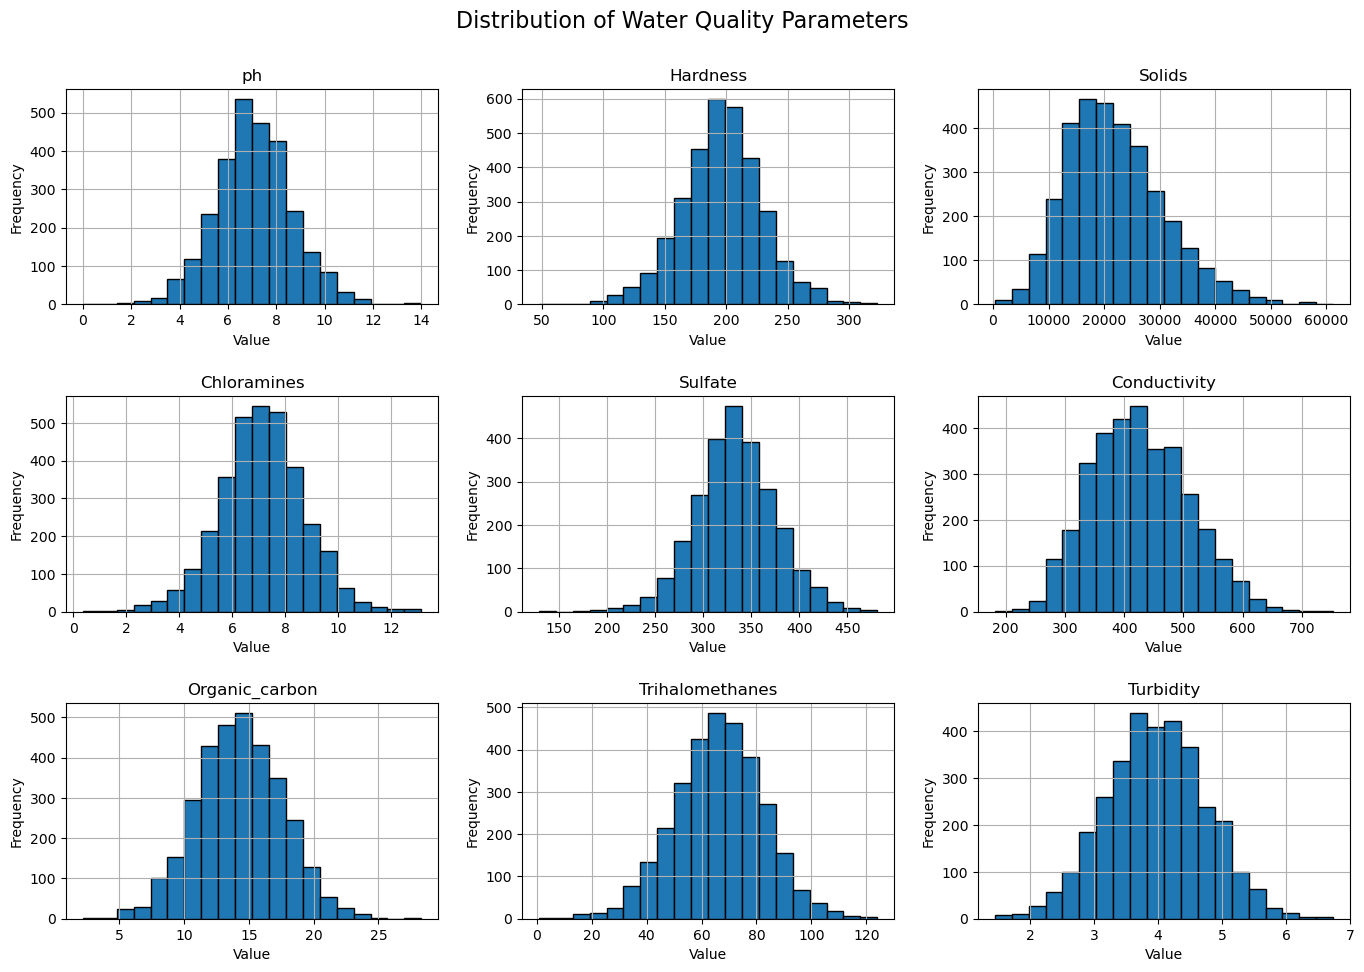

In [10]:
# Separate input features from the target variable
features = water.drop(columns=['Potability'])

# Generate histograms to analise the distribution of each feature
axes = features.hist(figsize=(14,10), bins=20, edgecolor='black')

# Configure axis labels for all subplots
for ax in axes.flatten():
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

# Add an overall title to the figure
plt.suptitle("Distribution of Water Quality Parameters", fontsize=16)

# Adjust spacing between subplots
plt.tight_layout(pad=2)

# Display plots
plt.show()

The **histograms** show that several variables present distributions that are approximately symmetric, with values concentrated around the central range of the data.<br>
However, some parameters such as **Solids** and **Conductivity** show slightly right-skewed distributions, where most observations are concentrated at lower values while fewer observations extend toward higher values.<br>
Other variables such as **pH**, **Hardness**, and **Chloramines** appear more symmetrically distributed around their central values.<br>
These patterns suggest that while most variables behave relatively consistently, some features may exhibit mild skewness, which will be examined further using skewness statistics in subsequent sections.

#### 5.5.2 Bivariate Distribution Analysis

The distribution of **variables in relation to the target variable (Potability)** is analysed to identify patterns, differences between classes and potential relationships that may be relevant for predictive modelling.

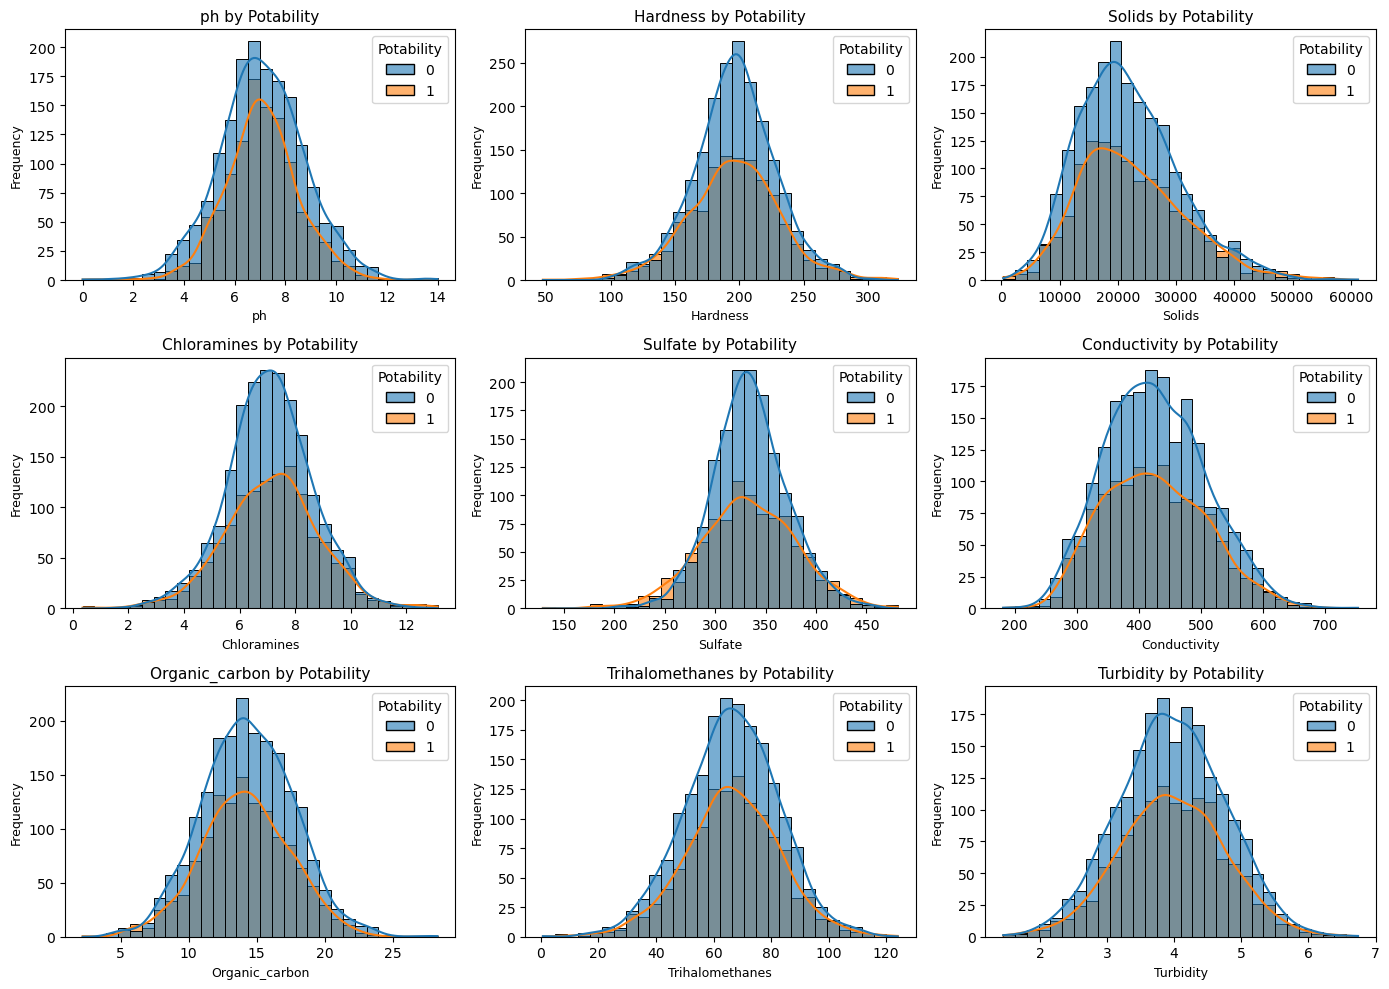

In [9]:
# Analyse feature distributions by target variable (Potability)

# Create figure and define layout
plt.figure(figsize=(14,10))

# Plot histograms for each feature grouped by Potability
for i, column in enumerate(features.columns, 1):
    plt.subplot(3, 3, i)    
    sns.histplot(data=water, x=column, hue='Potability', kde=True, bins=30, alpha=0.6 )    
    
    # Configure plot titles and axis labels
    plt.title(f'{column} by Potability', fontsize=11)
    plt.xlabel(column, fontsize=9)
    plt.ylabel('Frequency', fontsize=9)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

The **degree of overlap** between the distributions is a key factor in determining whether a variable can effectively distinguish between potable and non-potable water.<br>
A **strong overlap** occurs when both classes share a similar range of values along the horizontal axis, meaning that the same values are observed for both potable and non-potable samples. In such cases, the variable does not provide clear separation and is not sufficient for classification on its own.<br>
In contrast, a **weak overlap** occurs when the distributions are more separated, with each class occupying a different range of values. In this scenario, the variable can better distinguish between potable and non-potable water, making it more useful for predictive purposes.<br>
In this analysis, most variables show a **strong overlap**, indicating that they do not individually provide strong discriminatory power.<br>
It is also important to note that differences in the **height of the distributions** reflect differences in frequency rather than separation. Higher peaks indicate a greater number of observations for a given class. In this case, the higher peaks observed for non-potable water suggest the presence of a **class imbalance**, where one class contains more observations than the other.<br>
These findings indicate that individual variables alone are insufficient to accurately classify water potability. Therefore, it is necessary to consider **multiple variables simultaneously** to capture more complex relationships within the dataset.<br>
In practice, this involves using **machine learning models**, which can combine information from several features to improve predictive performance and  achieve more robust classification results.

### 5.6 Skewness Analysis

To complement the visual interpretation of the distributions, skewness is calculated for each numerical variable.

Skewness measures the degree of asymmetry in a distribution.
- Values **close to 0** indicate approximately **symmetric distribution**.
- **Positive** values indicate a **right-skewed** distribution (long tail to the right).
- **Negative** values indicate a **left-skewed** distributions (long tail to the left).

This analysis provides a quantitative assesssment of distribution shape, supporting the observations made from histograms. 

In [13]:
# Create an empty list to store skewness results
skewness_summary = []

# Loop through each column
for col in features.columns:
    data = features[col].dropna()  # Missing values are temporarily excluded from the analysis to ensure accurate statistical calculations
    skew_value = round(data.skew(), 3)
    # Restore results
    skewness_summary.append([col, skew_value])

# Convert list to DataFrame
skewness_table = pd.DataFrame(skewness_summary, columns=['Parameter', 'Skewness'])   

# Display table without index
skewness_table.style.hide(axis='index').format({'Skewness': '{:.3f}'})

Parameter,Skewness
ph,0.026
Hardness,-0.039
Solids,0.622
Chloramines,-0.012
Sulfate,-0.036
Conductivity,0.264
Organic_carbon,0.026
Trihalomethanes,-0.083
Turbidity,-0.008


The interpretation of skewness values can be summarised as follows:

| Skewness value | Interpretation |
|----------------|---------------|
| -0.5 to 0.5 | Approximately symmetric distribution |
| 0.5 to 1 or -0.5 to -1 | Moderately skewed distribution |
| > 1 or < -1 | Highly skewed distribution (possible candidate for transformation) |

The skewness results indicate that most variables are approximately symmetric.<br>
Some variables, particularly **Solids** and **Conductivity**, show moderate positive skewness, suggesting a slight **right-skewed** distributions.<br>
However, the magnitude of skewness across the variables is not extreme, indicating that the dataset does not exhibit strong asymmetry.

### 5.7 Correlation Analysis

Correlation Analysis examines the relationships between numerical variables in the dataset to determine how they change in relation to one another.<br>
It measures the strength and direction of the linear association between pairs of variables using correlation coefficients, which range from -1 to 1.
- A value **close to 1** indicates a **strong positive relationship**, meaning both variables tend to increase together.
- A value **close to -1** indicates a **strong negative relationship**, where one variable increases while the other decreases.
- A value **near 0** suggests little to **no linear relationship** between variables.

This analysis allows the identification of potential dependencies, redundant features and interactions between variables before applying machine learning models.

In [4]:
# Compute correlation matrix including target
corr_matrix = water.corr()

# Display correlaton matrix
corr_matrix

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


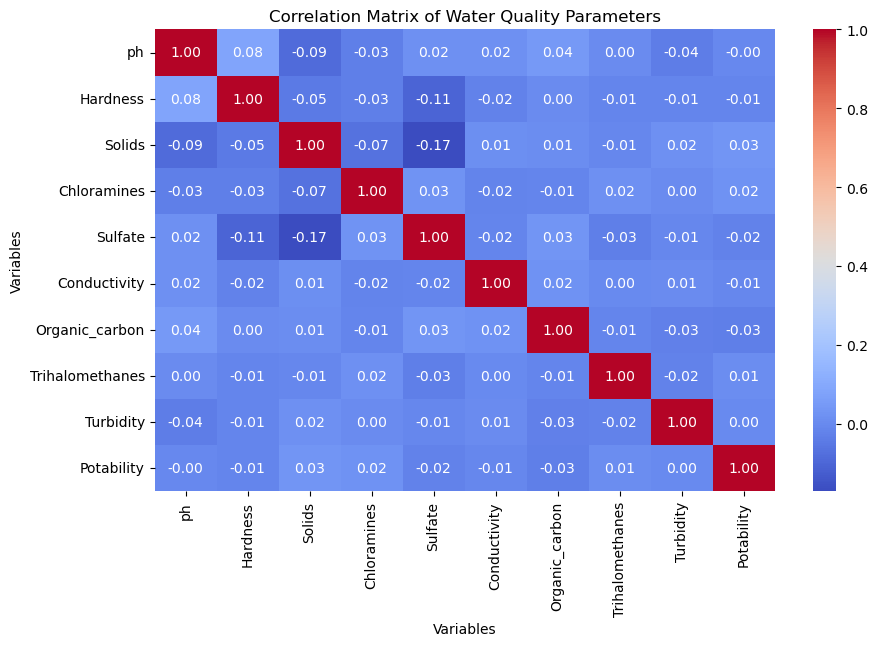

In [14]:
# Create correlation matrix for numerical variables
correlation_matrix = water.corr()

# Set figure size
plt.figure(figsize=(10, 6))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

# Add title and labels
plt.title('Correlation Matrix of Water Quality Parameters')
plt.xlabel('Variables')
plt.ylabel('Variables')

# Display plot
plt.show()

The interpretation of correlation coefficients can be summarised as follows:

| Correlation value | Interpretation |
|------------------------|----------------|
| 0.0 – ±0.3 | Very weak or no correlation |
| ±0.3 – ±0.5 | Weak correlation |
| ±0.5 – ±0.8 | Moderate correlation |
| ±0.8 – ±1.0 | Strong correlation (potential multicollinearity) |

The **Correlation Matrix of Water Quality Parameters** shows that most variables exhibit **very weak linear relationships**, with correlation coefficients close to zero. This indicates that water quality parameters largely vary independently from one another.<br>
No strong positive or negative correlations (values close to ±1) are observed, suggesting the **absence of strong linear dependencies** within the dataset. Consequently, **the risk of multicollinearity is low**, meaning that the features are not redundant and may contribute unique information to the model.<br>
In relation to the target variable (**Potability**), all correlations remain weak, indicating that **no single variable has a strong linear relationship** with water potability.<br>
Overall, these findings suggest that water potability cannot be explained by a single parameter alone, but rather by a **combination of multiple variables**, supporting the use of **multivariate machine learning models**.

### 5.8 Scatter Plot Analysis  

Scatter plots are used to examine the relationship between two variables by displaying individual data points in a two-dimensional space. This allows the visualization of patterns such as trends, dispersion and potential separation between classes.<br>
When a target variable is included (e.g., Potability), different colors can be used to distinguish between classes, helping assess whether the data points form distinct groups or overlap.<br>
A pairplot extends this analysis by showing scatter plots. 

#### 5.8.1 Scatterplot

A representative scatter plot is generated to examine the relationship between two selected variables (Turbidity and Sulfate) and their association with the target variable (Potability).<br>
This visualisation also helps identify potential patterns, clustering behavior and possible linear or non-linear relationships between variables.

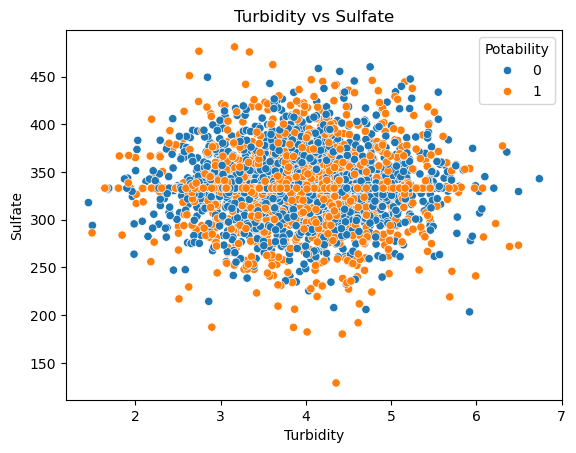

In [79]:
# Generate scatter plot
sns.scatterplot(data=water_imputation, x='Turbidity', y='Sulfate', hue='Potability')

# Set tables and labels
plt.title('Turbidity vs Sulfate')
plt.xlabel('Turbidity')
plt.ylabel('Sulfate')

# Display plot
plt.show()

The scatter plot of Turbidity vs Sulfate shows a **strong overlap** between potable and non-potable samples, where observations from both classes are highly intermixed. No clear linear separation or clustering pattern is observed between classes, suggesting that theses variables alone may not sufficiently differentiate water potability.

#### 5.8.2 Pairplot

A pairplot is used to visualize the relationships between all variables simultaneously by combinig multiple scatter and distributions plots in a single matrix. This allows the exploration of how feature combinations are distributed 
and how they relate to the target variable (Potability).<br>

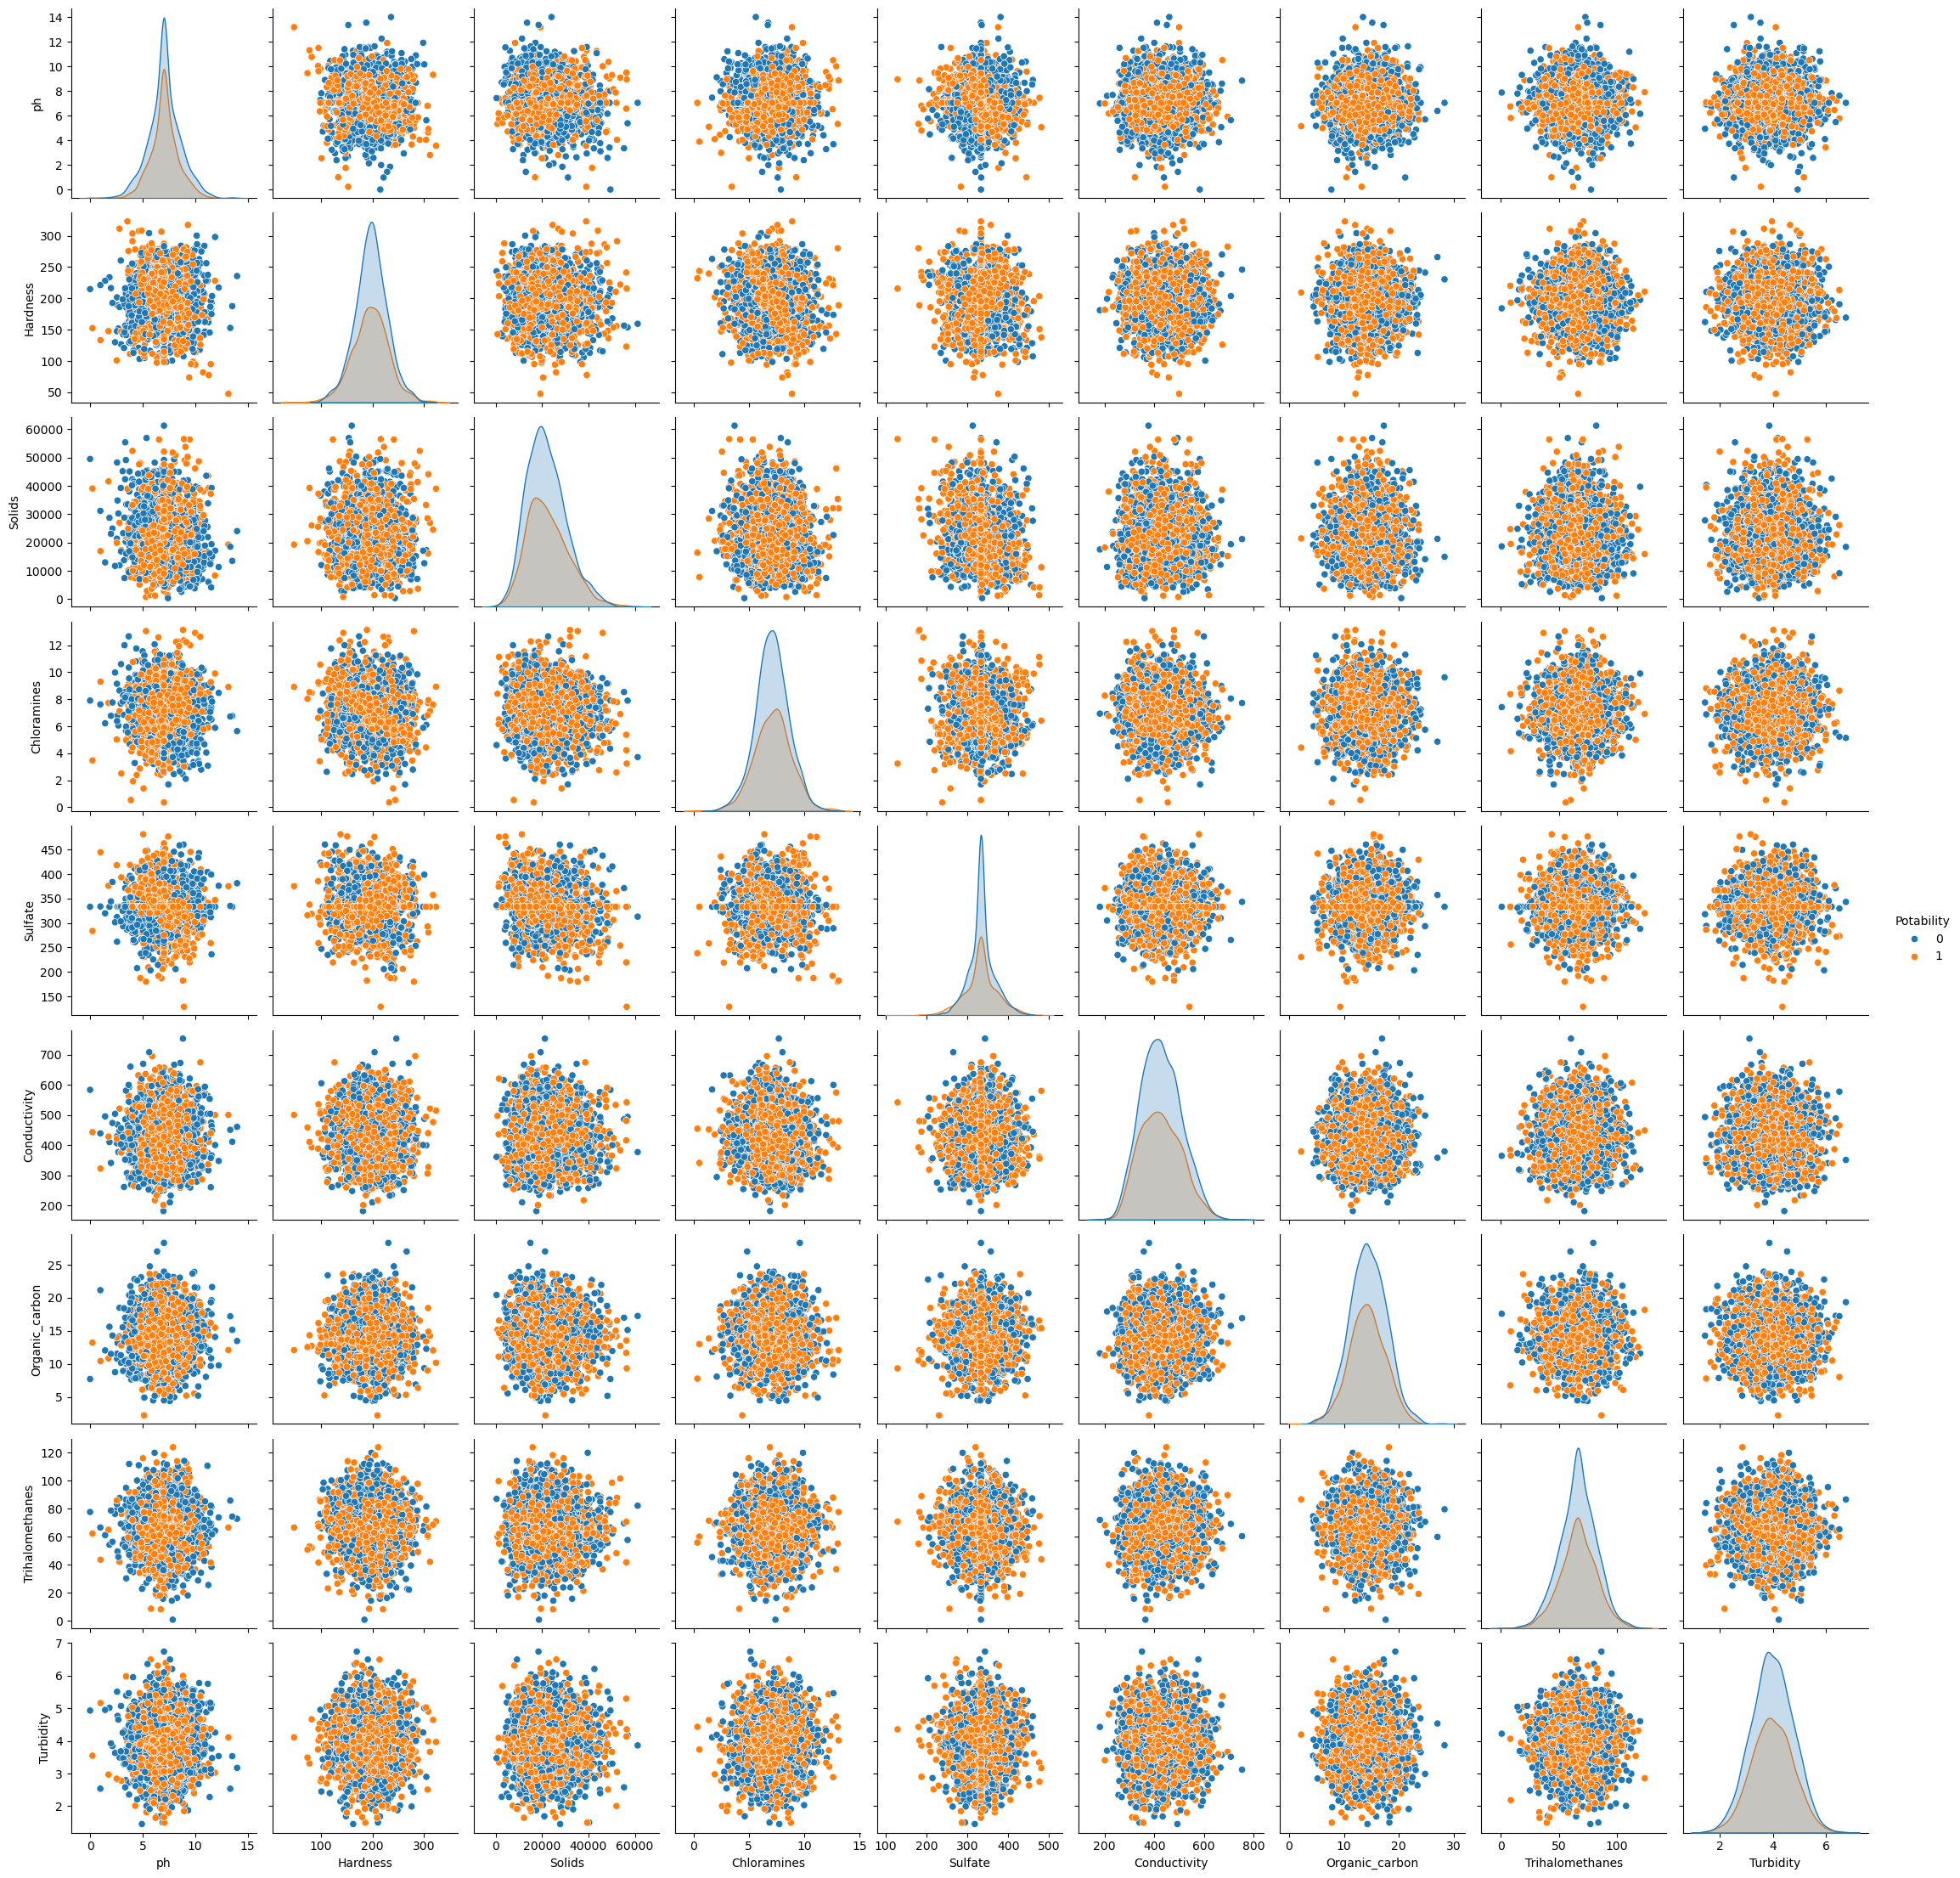

In [78]:
# Generate pairplot
sns.pairplot(water_imputation, hue='Potability', diag_kind='kde')

# Display plot
plt.show()

The pairplot confirms a **strong overlap** across multiple feature combinations, showing no clear linear separation or distinct clustering patterns between potable and non-potable classes. This suggests that water potability classification depends on the combined interaction of multiple variables rather than on a single feature independently.

### 5.9 Outlier Detection

Outliers are observations that differ significantly from the majority of the data.<br> 
Detecting potential outliers is an important step in exploratory data analysis, as extreme values may influence statistical summaries and machine learning models.<br>
In this study, boxplots are used as a visual tool to identify potential outliers in the water quality parameters.<br> 
It is important to note that, at this stage, outliers are only **identified and analysed**, while decisions regarding their treatment are addressed later during the **Data Preprocessing** stage. 

#### 5.9.1 Overview Boxplot Analysis

Boxplots are used to visually identify potential outliers in the dataset.<br> 
They summarise the distribution of each variable by displaying the **median**, **interquantile range (IQR)** and extreme values.<br> 
Observations that fall outside the whiskers may indicate potential outliers. The whiskers typically extend to 1.5 times the IQR bellow the first quartile (Q1) and above the third quartile (Q3).

The following diagram illustrates the main components of a boxplot:

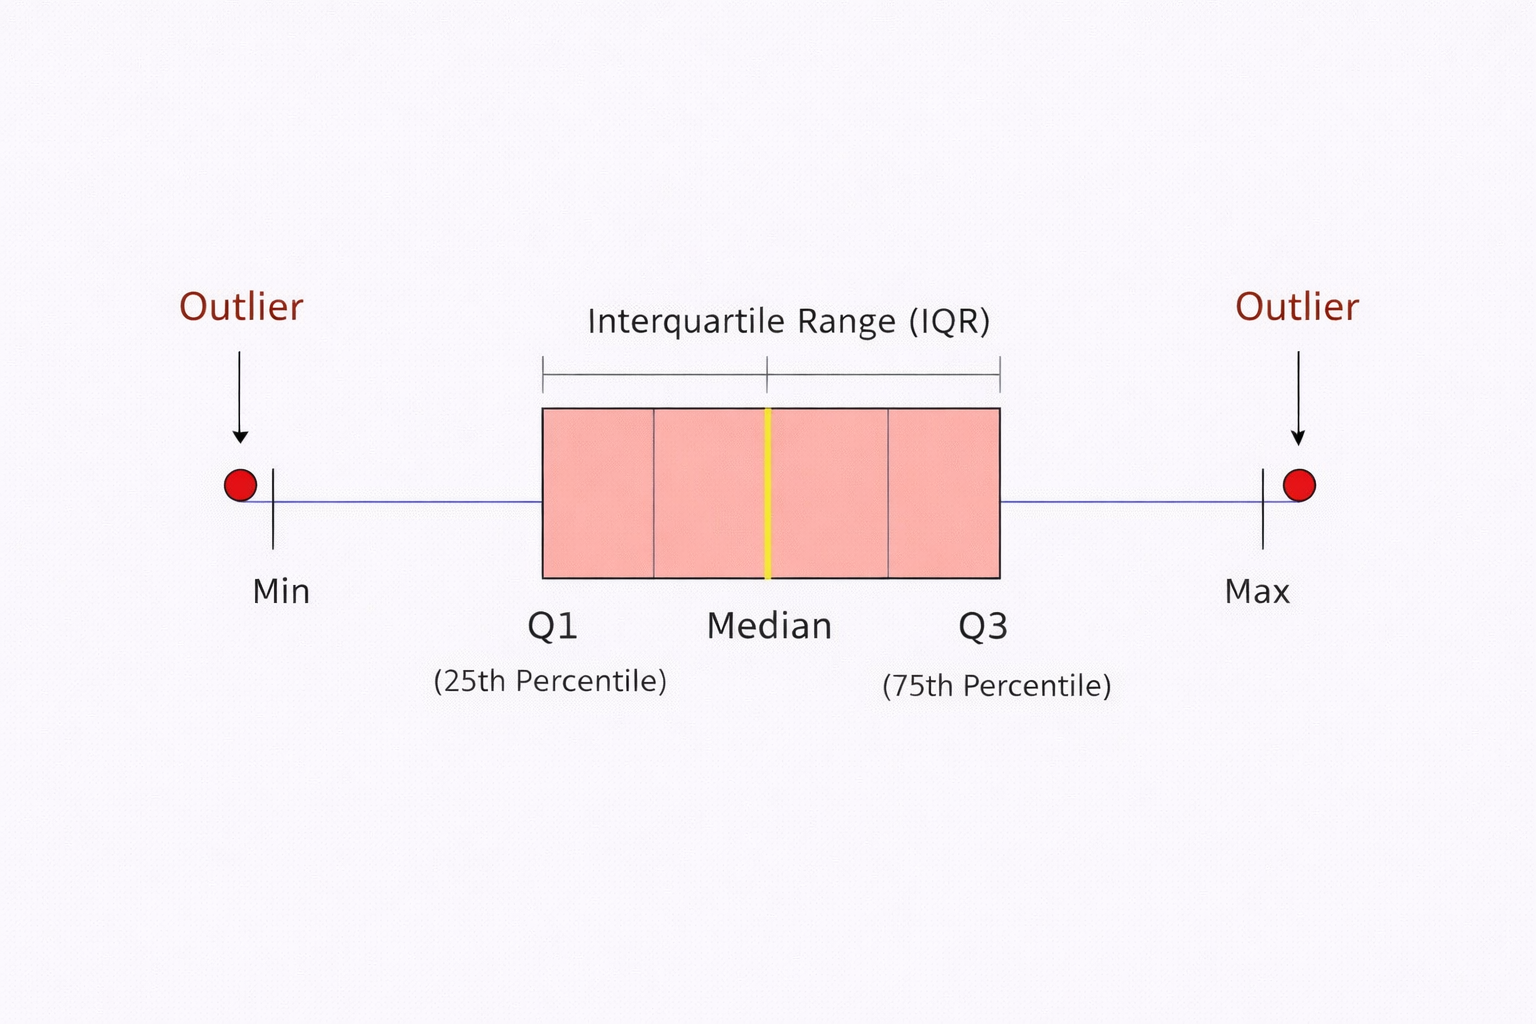

In [12]:
from IPython.display import Image, display
display(Image(filename='boxplot_components.png', width=600))

The Interquartile Range (IQR) method is used to identify potential outliers based on the spread of the data.

| Component        | Formula |
|------------------|---------|
| **IQR**          | Q3 - Q1 |
| **Lower Bound**  | Q1 - 1.5 × IQR |
| **Upper Bound**  | Q3 + 1.5 × IQR |

Outliers are defined as observations that fall outside this expected range.

- Values below the **lower bound** are considered lower outliers  
- Values above the **upper bound** are considered upper outliers

These limits define the typical spread of the data and any observations beyond them are considered potential outliers.

In a boxplot: 
<br>- The box represents the **interquartile range (IQR)**, which contains the middle 50% of the data
<br>- The line inside the box represents the **median**
<br>- The whiskers extend to the minimum and maximum values within the accepted range<
<br>- Values outside this range are considered **outliers**

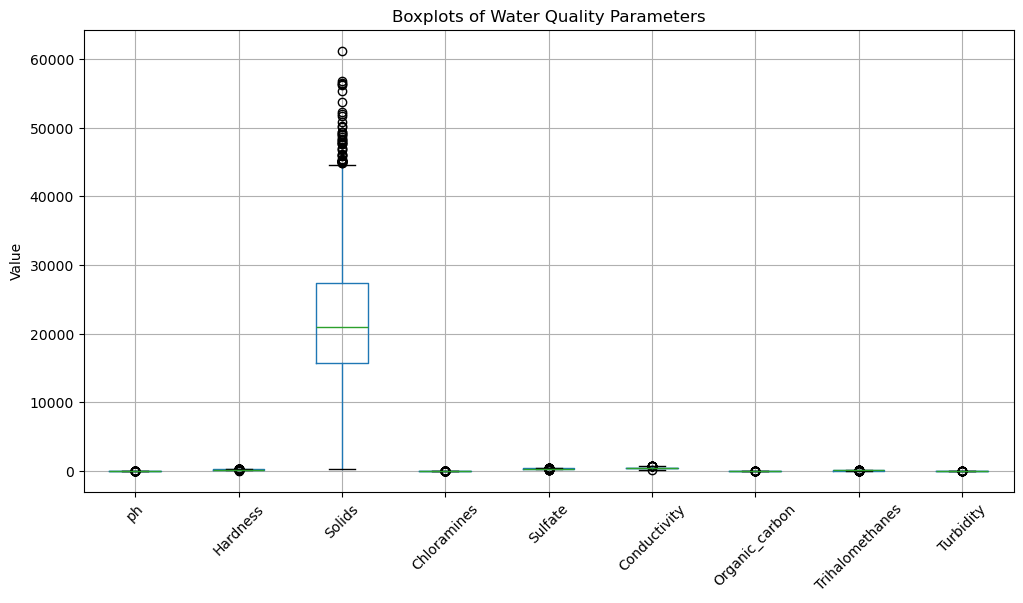

In [15]:
# Create boxplots for all variables and rotate x-axis labels
plt.figure(figsize=(12,6))
features.boxplot(rot=45)

# Add title and axis label
plt.title("Boxplots of Water Quality Parameters")
plt.ylabel("Value")

# Display the plot
plt.show()

The boxplot shows that several variables present values that extend beyond the typical range, indicating the presence of potential outliers.<br>
In particular, variables such as **Solids** exhibit a much wider range compared to other parameters, with numerous extreme values. This large variation affects the visualisation, making it difficult to clearly observe the distribution of variables with smaller scales.<br>
To obtain a more detailed understanding of outliers across individual features, separate boxplots are analysed in the following section.

#### 5.9.2 Univariate Boxplot Analysis

To improve the visualisation, boxplot are generated separately for each variable.<br>
This allows for a clearer observation of the distribution and potential outliers without the influence of the scale differences across variables.

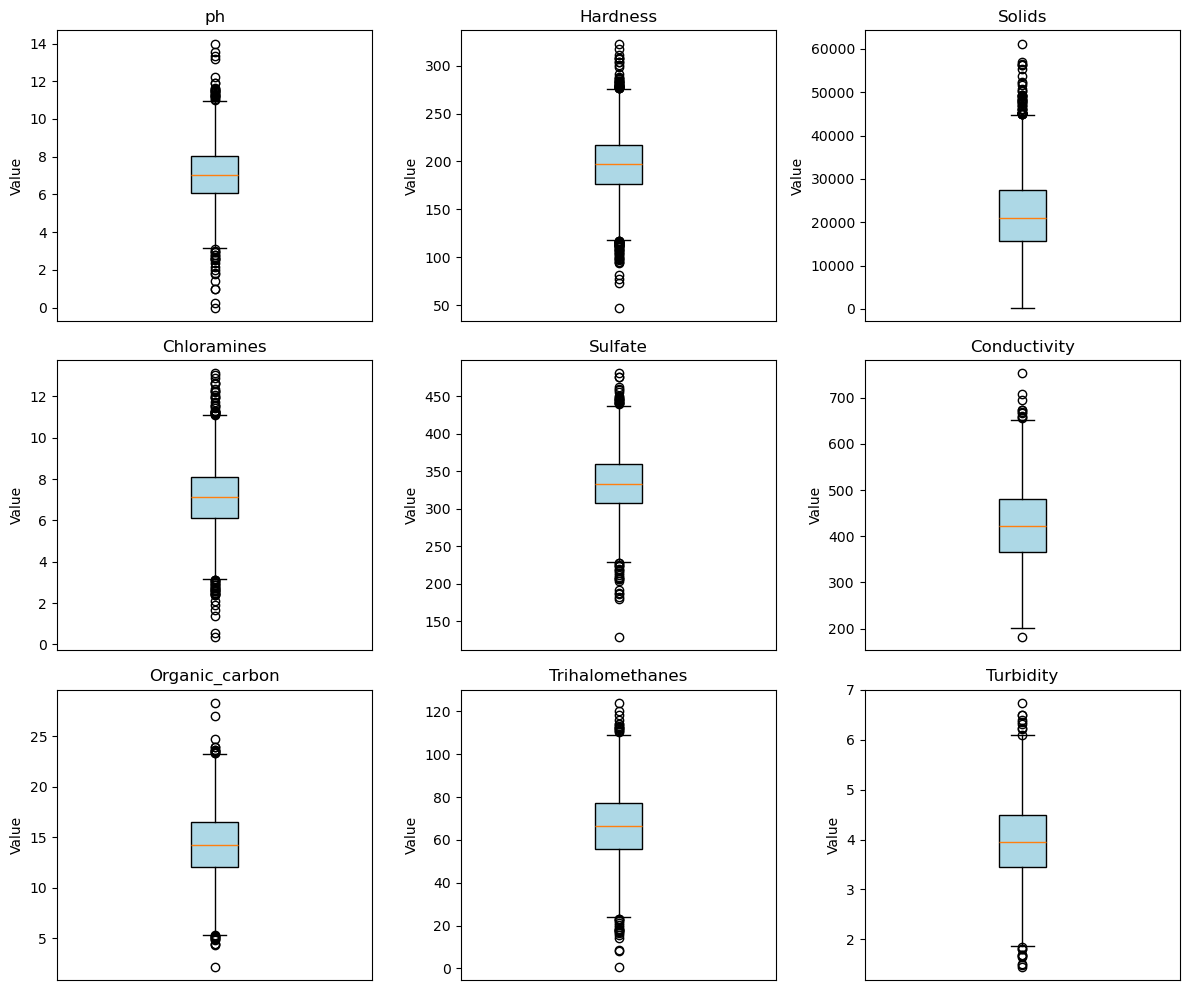

In [16]:
# Generate boxplots for each variable in a grid layout (3x3)

# Create boxplots in a grid layout
plt.figure(figsize=(12,10))

# Loop through each feaature to create individual boxplots 
for i, col in enumerate(features.columns, 1):
    plt.subplot(3,3,i)
    plt.boxplot(features[col].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
    
    # Add titles and labels
    plt.title(col)
    plt.ylabel("Value")

    # Remove '1' on x-axis
    plt.gca().set_xticks([])

# Adjust spacing between plots
plt.tight_layout()
plt.show()

The boxplots reveal the presence of outliers across most variables.<br>
This pattern is common in environmental datasets, where natural variability leads to fluctuations in water quality parameters.<br> 
Therefore, these values are not immediately considered errors, but will be further evaluated during the **Data Preprocessing** stage to determine whether they should be retained, transformed or removed.

#### 5.9.3 IQR Method

The IQR Method is used to identify outliers by measuring the spread of the central portion of the data. This method focuses on the range between the first quartile **(Q1)** and the third quartile **(Q3)**, which represents the middle 50% of the dataset.<br>
**Outliers** are defined as values that fall outside the **lower and upper limits** derived from this range, which are visualised as the whiskers in a boxplot.<br>
Unlike the Z-score method, the IQR approach does not rely on the mean or standard deviation, but instead is based on the **median and quartiles**. This maks it more robust and less sensitive to extreme values.<br> 
This method is particularly useful for **skewed distributions**, where extreme values may affect other statistical approaches.<br> 
In this case, although most variables show relatively low skewness and symmetric distributions, the IQR method is used as a complementary approach to compare results with other techniques.

In [15]:
# Identify outliers using IQR method for each variable

# Create an empty list to store outliers count
iqr_summary = []

# Loop through each feature column
for col in features.columns:
    data = features[col].dropna()  # Missing values are temporarily excluded from the analysis to ensure accurate statistical calculations    
    # Calculate IRQ
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3-Q1
    # Min and Max values 
    lower = Q1-1.5*IQR 
    upper = Q3+1.5*IQR 
    # Identify outliers
    outliers = data[(data < lower) | (data > upper)]
    # Store results
    iqr_summary.append([col, len(outliers)])

# Convert list to DataFrame
iqr_table = pd.DataFrame(iqr_summary, columns=['Parameter', 'Outliers'])   

# Display table without index
iqr_table.style.hide(axis='index')

Parameter,Outliers
ph,46
Hardness,83
Solids,47
Chloramines,61
Sulfate,41
Conductivity,11
Organic_carbon,25
Trihalomethanes,33
Turbidity,19


The **IQR results** show that outliers are present across all variables, although their frequency varies.<br>
Variables such as **Hardness** and **Chloramines** exhibit a higher number of outliers, indicating greater variability in their values. In contrast, parameters like **Conductivity** and **Turbidity** present fewer extreme values.<br>
These variations suggest that some water quality parameters are more sensitive to fluctuations than others, possibly due to differences in chemical composition or environmental influence.<br>
Overall, the presence of outliers is expected in environmental datasets, where natural variability and external factors can significantly influence measurements.<br>
Since the **IQR** method is based on the **median and quartiles**, it is more robust to extreme values, which explains its ability to detect a relatively higher number of outliers.<br> 
These results will be further compared with the Z-score and Percentile-based methods to evaluate differences in outlier detection.

#### 5.9.4 Z-score Method 

The Z-score Method is used to identify outliers by measuring how far each value is from the **mean** in terms of **standard deviations**.<br>
This approach standardizes the data so that the **mean becomes 0** and the **standard deviation becomes 1**, allowing values to be compared on the same scale.<br>
Values with a **Z-score greater than +3 or less than -3** are typically considered outliers.<br>
Unlike the IQR method, the Z-score approach relies on the **mean and standard deviation**, which makes it sensitive to extreme values. As a result, the presence of outliers can influence these statistics and potentially reduce the ability of the method to detect all extreme observations.<br>
This method is most appropriate for approximately **normal or symmetric distribution**.<br> 
In this case, since most variables show relatively low skewness and near-symmetric distributions, the Z-score method is considered suitable.<br>
However, for highly skewed variables, other methods such as the IQR or Percentile-based methods may be more reliable.

In [16]:
# Identify outliers using Z-score method for each variable

# Create an empty list to store outliers count
zscore_summary = []

# Loop through each feature column
for col in features.columns:  
    data = features[col].dropna()  # Missing values are temporarily excluded from the analysis to ensure accurate statistical calculations
    z_scores = zscore(data)    
    # Identify outliers (|z| > 3)
    outliers = data[(z_scores > 3) | (z_scores < -3)]    
    # Store results    
    zscore_summary.append([col, len(outliers)])

# Convert list to DataFrame
zscore_table = pd.DataFrame(zscore_summary, columns=['Parameter', 'Outliers'])

# Display table without index
zscore_table.style.hide(axis='index')

Parameter,Outliers
ph,16
Hardness,18
Solids,20
Chloramines,20
Sulfate,17
Conductivity,7
Organic_carbon,4
Trihalomethanes,12
Turbidity,9


The **Z-score results** show a lower number of detected outliers compared to the **IQR** method.<br>
Most variables present relatively few extreme values, indicating that the majority of the data is concentrated around the **mean**.
Paramaters such as **Solids**, **Chloramines** and **Hardness**, which showed a high number of outliers using the **IQR** method, still present the highest number of outliers in this approach, although at a reduce level.<br>
These differences suggest that the **Z-score** method is more restrictive in detecting outliers, as it depends on the **mean and standard deviation**, which can be influenced by extreme values.<br>
Overall, these results confirm that the choice of method can significantly influence the identification of outliers in the dataset.

#### 5.9.5 Percentile-based Method 

The Percentile-based Method is used to identify outliers by defining thresholds based on fixed percentiles, such as the **1st percentile (P1)** and the **99th percentile (P99)**.<br>
Values that fall below **P1** or above **P99** are considered extreme and may be classified as outliers.<br>
Unlike the IQR and Z-score methods, this approach does not rely on the **mean**, **median**, or **standard deviation**, but instead uses the relative position of values within the dataset.<br>
This method does not assume any specific data distribution and is useful for **skewed distributions** or datasets with irregular patterns.<br>
However, since the thresholds are fixed, the method may be sensitive to the choice of percentiles and may either overestimate or underestimate the number of outliers depending on the data.<br>
In this study, the Percentile-based Method is applied as an additional reference to compare results with the **IQR and Z-score** methods.

In [17]:
# Create an empty list to store outliers count
percentile_summary = []

# Loop through each feature column
for col in features.columns:   
    # Drop missing values
    data = features[col].dropna()    
    # Calculate percentiles
    lower_bound = data.quantile(0.01)   # P1
    upper_bound = data.quantile(0.99)   # P99   
    # Identify outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]    
    # Count outliers
    outlier_count = len(outliers)   
    # Append results
    percentile_summary.append([col, outlier_count])

# Convert list to DataFrame
percentile_table = pd.DataFrame(percentile_summary, columns=['Parameter', 'Outliers'])

# Display table without index
percentile_table.style.hide(axis='index').format({'Outliers': "{:.0f}"})

Parameter,Outliers
ph,56
Hardness,66
Solids,66
Chloramines,66
Sulfate,50
Conductivity,66
Organic_carbon,66
Trihalomethanes,64
Turbidity,66


The **Percentile-based results** detect a higher number of outliers across most variables. Several parameters, such as **Hardness**, **Solids**, **Chloramines**, **Conductivity**, **Organic Carbon**, and **Turbidity**, show similar outlier counts, indicating the presence of extreme values in multiple variables.<br>
Compared to the **Z-score** method, this approach identifies more outliers, as it does not rely on the **mean** or **standard deviation**, but instead uses fixed **percentiles** to define thresholds.<br>
This explains why the method is more sensitive in detecting extreme values, since any observation falling outside the selected percentile range is automatically considered an outlier.<br>
However, this approach may also include values that are not necessarily abnormal, but part of the natural variability of the dataset.

#### 5.9.6 Comparison of Outliers Detection Methods

Outliers were identified using three different approaches: **IQR**, **Z-score** and **Percentile-based** methods.<br>
The **IQR** method detected the highest number of outliers across most variables. This is because it is based on the **median** and is more robust to variability, making it suitable for environmental datasets.<br>
The **Z-score** method identified fewer outliers, as it relies on the **mean and standard deviation**, making it more sensitive to extreme values and more appropriate for approximately **normal distributions**.<br>
The **Percentile-based** method also detected a relatively high number of outliers, as it uses fixed thresholds. However, this method may include values that are part of the natural variability of the dataset.<br>
Considering that most variables show relatively **low skewness and near-symmetric distributions**, the **Z-score** method is selected as the preferred approach for this study.<br>
The **IQR and Percentile-based** methods are used as complementary references to better understand data variability.

### 5.10 EDA Summary

The **EDA** provided a clear understanding of the dataset, including its structure, variable distributions, relationships between features and the presence of potential outliers.<br>
The analysis revealed that most variables exhibit **weak individual relationships with the target variable**, indicating that water potability cannot be accurately determined by a single parameter alone.<br>
Additionally, the application of multiple outlier detection methods **(IQR, Z-score and Percentile-based)** enabled a robust evaluation of extreme values, supporting the selection of the most appropriate technique for subsequent analysis.<br>
Overall, the findings highlight the need for **multivariate modelling approaches**, where multiple features are considered simultaneously to capture complex patterns within the data.<br>
Inferential statistical analysis was not conducted, as the focus of this study is on **exploratory analysis and predictive modelling** rather than hypothesis testing.

## 6. Data Quality Assessment

Data Quality Assessment is a crucial step prior to **Data Preprocessing**, as it ensures the reliability and validity of subsequent analysis and machine learning modeling. This stage focuses on identifying potential data quality issues that may affect model performance, particularly missing values, duplicate records, and data consistency.<br>
Building upon the insights obtained during the **EDA**, this chapter evaluates the overall integrity of the dataset and provides a foundation for selecting appropriate preprocessing strategies.

In this study, the data quality assessment consists of the following key components:
<br>- **Missing Values Analysis**, to evaluate the presence, distribution and impact of incomplete data.
<br>- **Duplicate Data Analysis**, to verify whether redundant observations exist in the dataset.

Overall, this stage ensures that the dataset is **reliable, consistent and suitable** for further preprocessing and modelling.

### 6.1 Missing Values Analysis

Missing Values are a critical aspect of data quality, as incomplete data can negatively impact both statistical analysis and machine learning model performance.<br>
In this section, missing values are identified and analysed to understand their distribution across the dataset. This includes evaluating their overall quantity, their distribution across variables and their potential impact on the dataset.<br>
This analysis provides a clear understanding of data completeness and serves as the basis for selecting an appropriate handling strategy in the subsequent **Data Preprocessing** stage.

#### 6.1.1 Detection of Missing Values

The total number of missing values in the dataset is calculated to assess the overall completeness of the data.

In [18]:
# Calculate total number of missing values
missing_total = water.isnull().sum().sum()

# Display result
print("Total number of missing values in the dataset:", missing_total)

Total number of missing values in the dataset: 1434


A total of **1,434 missing values** were detected across the dataset. This indicates the presence of incomplete observations that should be addressed before model training, as machine learning algorithms require complete numerical input.

#### 6.1.2 Distribution of Missing Values per Column

The distribution of missing values across **variables (columns)** is examined, focusing on the number and proportion of missing entries in each variable. This analysis shows how missing data is distributed among the features of the dataset.

In [19]:
# Create Missing Values and Percentage Summary per Column

# Create an empty list to store missing values summary
missing_col_summary = []

# Loop through each column
for col in water.columns:
    missing_col_count = water[col].isnull().sum()
    missing_col_percentage = (missing_col_count/len(water))*100
    # Append results as dictionary
    missing_col_summary.append({"Parameter": col, "Missing Values per Column": missing_col_count, 
                                "Missing Percentage (%)": round(missing_col_percentage, 3)})

# Convert list to DataFrame
missing_col_df = pd.DataFrame(missing_col_summary)

# Sort values from highest to lowest missing values
missing_col_df = missing_col_df.sort_values(by="Missing Values per Column", ascending=False)

# Reset index
missing_col_df = missing_col_df.reset_index(drop=True)

# Display table without index
missing_col_df.style.hide(axis="index").format({'Missing Percentage (%)': "{:.3f}"})

Parameter,Missing Values per Column,Missing Percentage (%)
Sulfate,781,23.840
ph,491,14.988
Trihalomethanes,162,4.945
Hardness,0,0.000
Solids,0,0.000
Chloramines,0,0.000
Conductivity,0,0.000
Organic_carbon,0,0.000
Turbidity,0,0.000
Potability,0,0.000


The Missing Values per Column (column-wise) shows that missing data is concentrated in three variables: **Sulfate**, **pH** and **Trihalomethanes**, while the remaining features contain no missing observations. This indicates that missingness is not uniformly distributed, but instead affects specific water quality parameters.  
The corresponding **Missing Percentage (%)** confirms that **Sulfate** has the highest proportion of missing data, followed by **pH** and **Trihalomethanes**, suggesting that certain variables are more affected than others.<br> 
From a data quality perspective, it is generally recommended to consider removing a variable when it contains a high proportion of missing values, typically around **40–50% or more**. However, in this dataset, the maximum proportion is approximately **24% (Sulfate)**, which is below this threshold.<br>
Therefore, removing columns is not justified, and **imputation techniques** are considered the most appropriate strategy.

#### 6.1.3 Distribution of Missing Values per Row

The distribution of missing values across **observations (rows)** is analysed, focusing on how many missing entries are present within each observation. This perspective provides insight into how missing data is distributed across individual records in the dataset.

In [17]:
# Create Missing Values and Percentage Summary per Row

# Create an empty list to store results
missing_row_summary = []

# Count missing values per row
missing_row_count = water.isnull().sum(axis=1)

# Loop through each unique missing value count
for count in sorted(missing_row_count.unique()):
    # Calculate number of rows with this missing count
    row_frequency = (missing_row_count == count).sum()   
    # Calculate percentage
    missing_row_percentage = (row_frequency / len(water)) * 100   
    # Append results as dictionary
    missing_row_summary.append({ "Missing Values per Row": count, "Number of Rows": row_frequency, 
                                "Missing Percentage (%)": round(missing_row_percentage, 3)})

# Convert list to DataFrame
missing_row_df = pd.DataFrame(missing_row_summary)

# Sort values from highest to lowest missing values
missing_row_df = missing_row_df.sort_values(by="Missing Values per Row", ascending=False)

# Reset index
missing_row_df = missing_row_df.reset_index(drop=True)

# Display table without index
missing_row_df.style.hide(axis="index").format({"Missing Percentage (%)": "{:.3f}"})

Missing Values per Row,Number of Rows,Missing Percentage (%)
3,9,0.275
2,151,4.609
1,1105,33.730
0,2011,61.386


The Missing Values per Row (row-wise) provides insight into how missing data is spread across observations. Most rows contain no missing values, while a smaller proportion includes one or more missing entries.<br> 
Overall, missing data is relatively **sparse and dispersed across observations**, rather than concentrated within specific rows.<br>
A common guideline suggests removing rows when a high proportion of their values are missing (typically **40–50% or more**). In this dataset, the maximum is **3 out of 10 variables (30%)**, which is below this threshold.<br>
Therefore, removing rows is not justified, further supporting the use of **imputation techniques**.

#### 6.1.4 Missing Data Visualisation

A visual representation of missing values across the dataset is provided. The heatmap allows for a clear identification of where missing values occur across columns and how they are distributed across rows, facilitating a better understanding of the overall missing data structure.

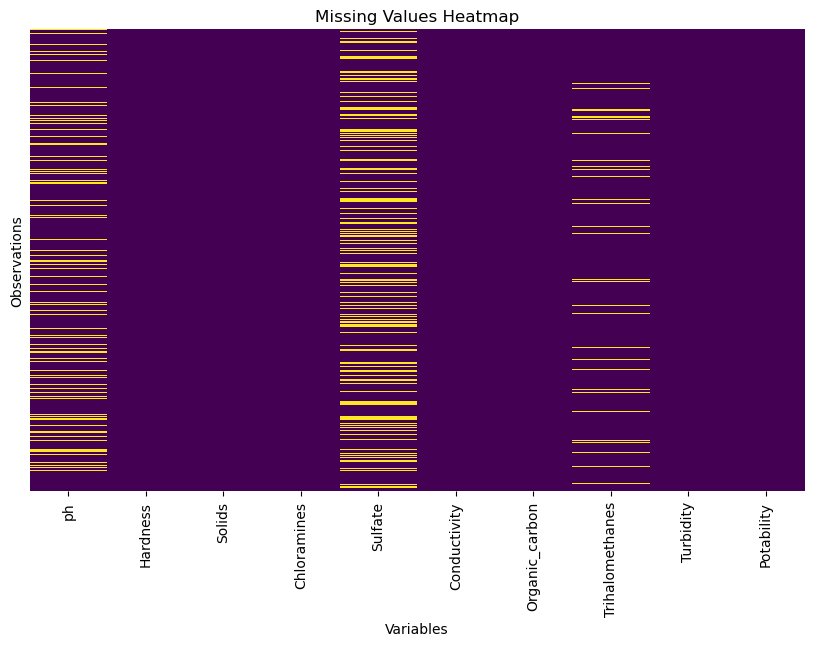

In [18]:
# Show Missing Data Distribution Visualisation 

# Set figure size
plt.figure(figsize=(10,6))

# Create heatmap to visualise missing values
sns.heatmap(water.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Add title to the plot
plt.title('Missing Values Heatmap')
plt.xlabel('Variables')
plt.ylabel('Observations')

# Display the plot
plt.show()

The Missing Data Visualisation confirms the patterns observed in both the column-based and row-based analyses. Missing values are primarily concentrated in **Sulfate, pH, and Trihalomethanes**, while the remaining variables are complete.<br>
From a row perspective, missing values are distributed across many observations, with **most rows containing zero or one missing value**. There is no evidence of rows with a high concentration of missing values.<br>
Additionally, the absence of clear **clusters (groups of observations with many missing values)** indicates that missing data does not follow a structured pattern, but instead occurs randomly across the dataset.<br>
This visual evidence further supports the use of **imputation techniques** rather than removing rows or columns.

#### 6.1.5 Missing Data Correlation

Missing Data Correlation examines the relationship between missing values across variables to determine whether missingness occurs simultaneously.<br>
Unlike the standard **Correlation Analysis of Numerical Values**, this approach focuses patterns of data absence rather than actual values.<br> 

- A value **close to 1** indicates that **missing values in two variables tend to ocurr in the same observations**
- A value **close to 0** indicates that **missing values occur independently** between variables

Understanding these relationships is important for selecting appropriate data handling strategies, particularly when deciding whether variables can be imputed separately or require more advanced techniques.

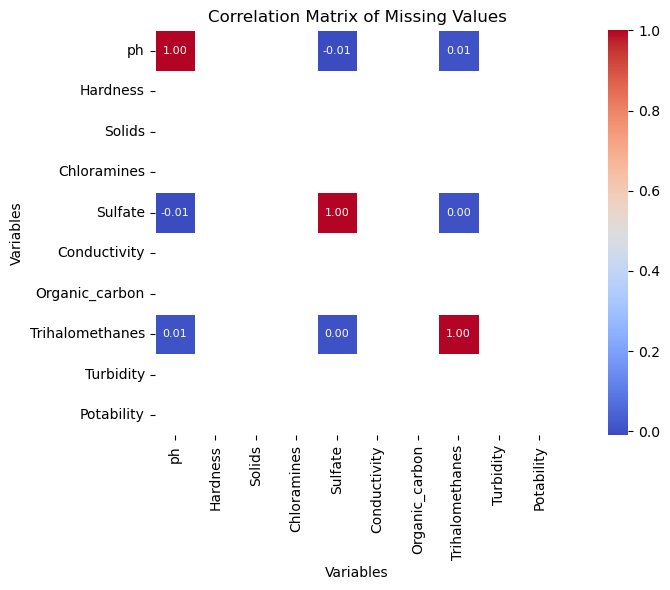

In [19]:
# Create missing values correlation matrix
missing_corr = water.isnull().corr()

# Set figure size
plt.figure(figsize=(10,6))

# Plot heatmap
sns.heatmap(missing_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True, square=True, annot_kws={'size':8})

# Add titles and labels
plt.title("Correlation Matrix of Missing Values", fontsize=12)
plt.xlabel('Variables')
plt.ylabel('Variables')

# Improve layouts
plt.tight_layout()

#Show plot
plt.show()

The **Correlation Matrix of Missing Values** shows that the **relationships** between missing values across variables are **very weak**, with coefficients close to zero. This indicates that missingness does not occur simultaneously across variables and that there is no systematic pattern of missing data shared between them.<br>
In practical terms, this means that when a value is missing in one variable, it does not imply that values are also missing in other variables. Therefore, missing values can be treated independently for each feature.<br>
As a result, simple imputation techniques such as **mean or median** imputation are appropriate, as there is no need to apply more complex multivariate imputation methods.

### 6.2 Duplicate Data Analysis

Duplicate records are analysed to identify any repeated observations in the dataset.<br> 
Duplicate data can negatively affect the reliability of statistical analysis and machine learning models, as it may introduce bias or over-representation of certain patterns.

In [34]:
# Calculate total number of duplicated rows
duplicate_count = water.duplicated().sum()

# Display result
print(" Total number of duplicated rows in dthe dataset:", duplicate_count)

 Total number of duplicated rows in dthe dataset: 0


A total of **0 duplicated rows** were detected in the dataset. This confirms that there are no repeated observations and no risk of data redundancy.<br>
As a result, no duplicate removal is required, and the dataset is considered clean with respect to duplicated records.

## 7. Data Preprocessing

Data Preprocessing is a crucial stage in the machine learning workflow, focused on preparing the dataset for modelling after the **EDA** and **Data Quality Assessment** stages.

In this study, the preprocessing workflow consists of three main steps:
<br>- **Data Cleaning**, to handle missing values and improve dataset consistency.
<br>- **Data Validation After Cleaning**, to verify that data distributions remain stable after preprocessing.
<br>- **Feature Engineering**, to prepare the dataset for machine learning modelling through scaling, transformation, multicollinearity and feature relevance prior to modelling.

Overall, this stage ensures that the dataset is **clean, consistent and properly prepared** for subsequent modelling.

### 7.1 Data Cleaning

Data Cleaning is a fundamental step within **Data Preprocessing**, focused on correcting data quality issues identified during the previous analysis stage. This includes handling missing values and ensuring that the dataset is complete and consistent for subsequent modelling.<br>
Based on the **Data Quality Assessment**, the primary issue identified in this dataset is the presence of missing values, while no duplicate records are found. Therefore, the cleaning process focuses on addressing missing data appropriately.

#### 7.1.1 Missing Value Handling

Missing values are adressed using an imputation strategy informed by the **Data Quality Assessment**.<br>
**Row removal is not considered appropriate**, as missing are distributed across the dataset rather than concentrated in specific observations. Removing rows would significantly reduce the dataset size without substantial benefit.<br>
Similarly, **column removal is not justified**, since the proportion of missing values remains below commonly accepted thresholds (typically 40–50%). Additionally, the affected variables (pH, Sulfate and Trihalomethanes) are important water quality indicators and should be retained.<br>
Based on the **Distribution Analysis**, most variables are approximately symmetric, with the presence of some outliers. Since mean imputation is sensitive to extreme values, **median imputation was selected** as a more robust approach.<br>
Therefore, missing values in pH, Sulfate and Trihalomethanes were imputed using the median of each variable.

#### 7.1.2 Median Imputation

Median imputation is applied to the dataset by replacing missing values with the **median** of each corresponding variable. This approach ensures that missing values are handled in a consistent and robust manner.

In [4]:
# Create a copy of the original dataset
water_imputation = water.copy()

# Loop through each column
for col in water_imputation.columns:
    # Check if the column has missing values
    if water_imputation[col].isnull().sum() > 0:
        #Replace missing values with the median of the column
        water_imputation[col] = water_imputation[col].fillna(water_imputation[col].median())

#### 7.1.3 Post-Imputation Verification

After applying median imputation, the dataset is evaluated to verify whether missing have been successfully handled.<br>
This step ensures that the imputation process has been correctly implemented across all variables and that no incomplete data remains before proceeding to further analysis.

In [5]:
# Show the number of missing values in each column after imputation
water_imputation.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

The results indicate that all missing values have been successfully replaced across the dataset. This confirms that the imputation process has been correctly applied and that the dataset no longer contains incomplete observations.

#### 7.1.4 Final Dataset Overview

The final dataset is reviewed to confirm its structure and ensure that the data is ready for subsequent preprocessing and modelling steps.

In [23]:
# Display the first rows of the cleaned dataset
water_imputation.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [24]:
# Display dataset dimensions after cleaning
water_imputation.shape

(3276, 10)

The dataset preview shows that all variables contain valid numerical values and are consistently formatted.<br> 
Additionally, the dataset dimensions remain unchanged after cleaning, indicating that no observations were removed and only missing values were handled through imputation. The dataset is now complete and properly structured for further analysis.

### 7.2 Data Validation After Cleaning

After completing the **Data Cleaning** process, it is essential to validate that the transformations applied have not introduced unintended distortions in the dataset.<br>
This stage focuses on verifying that the statistical properties, distributions and relationships between variables and the target remain consistent after handling missing values.<br>
To achieve this, the distribution of the variables are re-examined and compared with their original patterns observed during the **EDA** stage. Tis includes analysing **Histograms** to assess distribution shape and **Boxplots** to evaluate the presence of extreme values.<br>
Additionally, the relationship between features and the target variable is reassessed to ensure that class separation patterns remain stable after data cleaning.<br>
This validation step ensures that the dataset remains **reliable, consistent and suitable** for subsequent **Feature Engineering** and model development stages.

#### 7.2.1 Bivariate Distribution Analysis (After Cleaning) 

The distribution of variables in relation to the target variable (Potability) was previously analysed during the **EDA** stage.<br> 
Following the **Data Cleaning** process, the analysis is revisited to assess whether the imputation of missing values has altered the underlying distributions or relationships between variables and the target.<br>
This step ensures that the dataset remains consistent and that no significant distortions have been introduced during preprocessing.

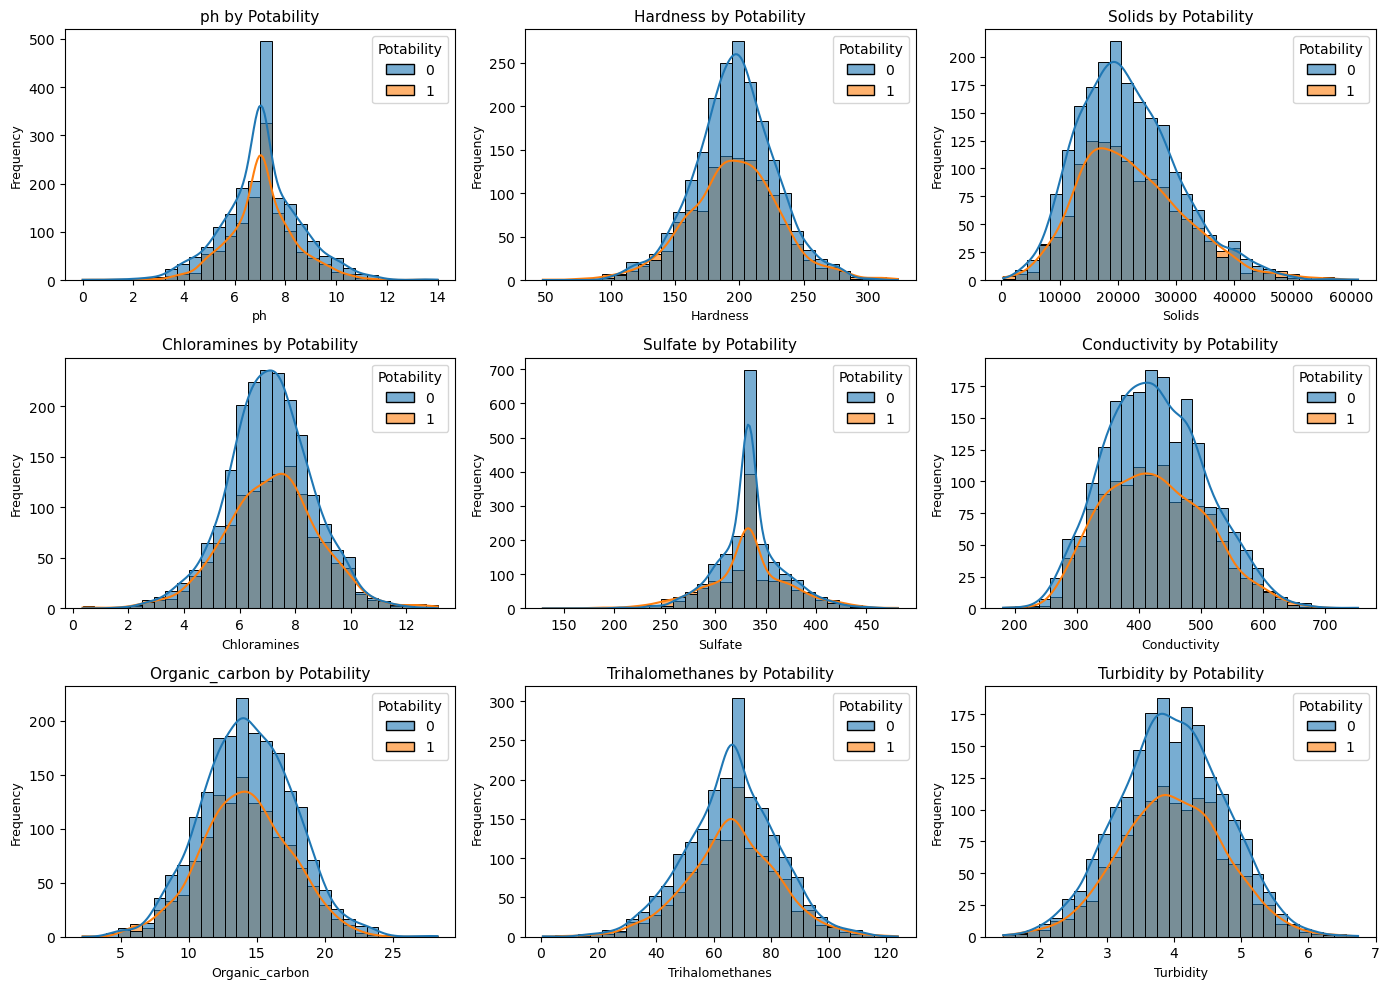

In [25]:
# Analyse feature distributions by target variable (Potability)

# Create figure and define layout
plt.figure(figsize=(14,10))

# Plot histograms for each feature grouped by Potability
for i, column in enumerate(features.columns, 1):
    plt.subplot(3, 3, i)    
    sns.histplot(data=water_imputation, x=column, hue='Potability', kde=True, bins=30, alpha=0.6 )    
    
    # Configure plot titles and axis labels
    plt.title(f'{column} by Potability', fontsize=11)
    plt.xlabel(column, fontsize=9)
    plt.ylabel('Frequency', fontsize=9)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

After the imputation process, slight changes in the distribution are observed only in variables that originally contained missing values, namely pH, Sulfate and Trihalomethanes.<br>
These variables **exhibit noticeable peaks around specific values**, which are not present in the original distributions. This effect is a direct consequence of median imputation, where missing values are replaced by a single constant value (**the median**), leading to an artificial concentration of observations at that point.<br>
Despite this localized distortion, the overall shape of the distributions remains largely consistent with the original data. Therefore, the imputation process does not significantly alter the general structure of the dataset.<br>
This trade-off is acceptable because, although median imputation introduces a concentration of values at a single point, it provides robustness against outliers and preserves the overall structure of the data.

#### 7.2.2 Feature vs. Target Analysis (Boxplots)

To further explore the relationship between individual features and the target variable, boxplots are used to compare the distribution of each variable across the **two classes: non-potable water (0) and potable water (1)**.<br>
This analysis represents a **Bivariate Boxplot Analysis**, where each feature is examined in relation to the target variable (Potability). The goal is to assess whether a variable shows different distributions between the two classes.<br> 
A feature is considered to have discriminative power when the boxplots for each class show clear separation, particularly in their median values and interquartile ranges. In contrast, when there is significant overlap between the boxplots, the variable does not effectively distinguish between potable and non-potable water.<br>
Therefore, this analysis indicates which variables may contribute more effectively to classification and which ones provide limited information when considered individually.

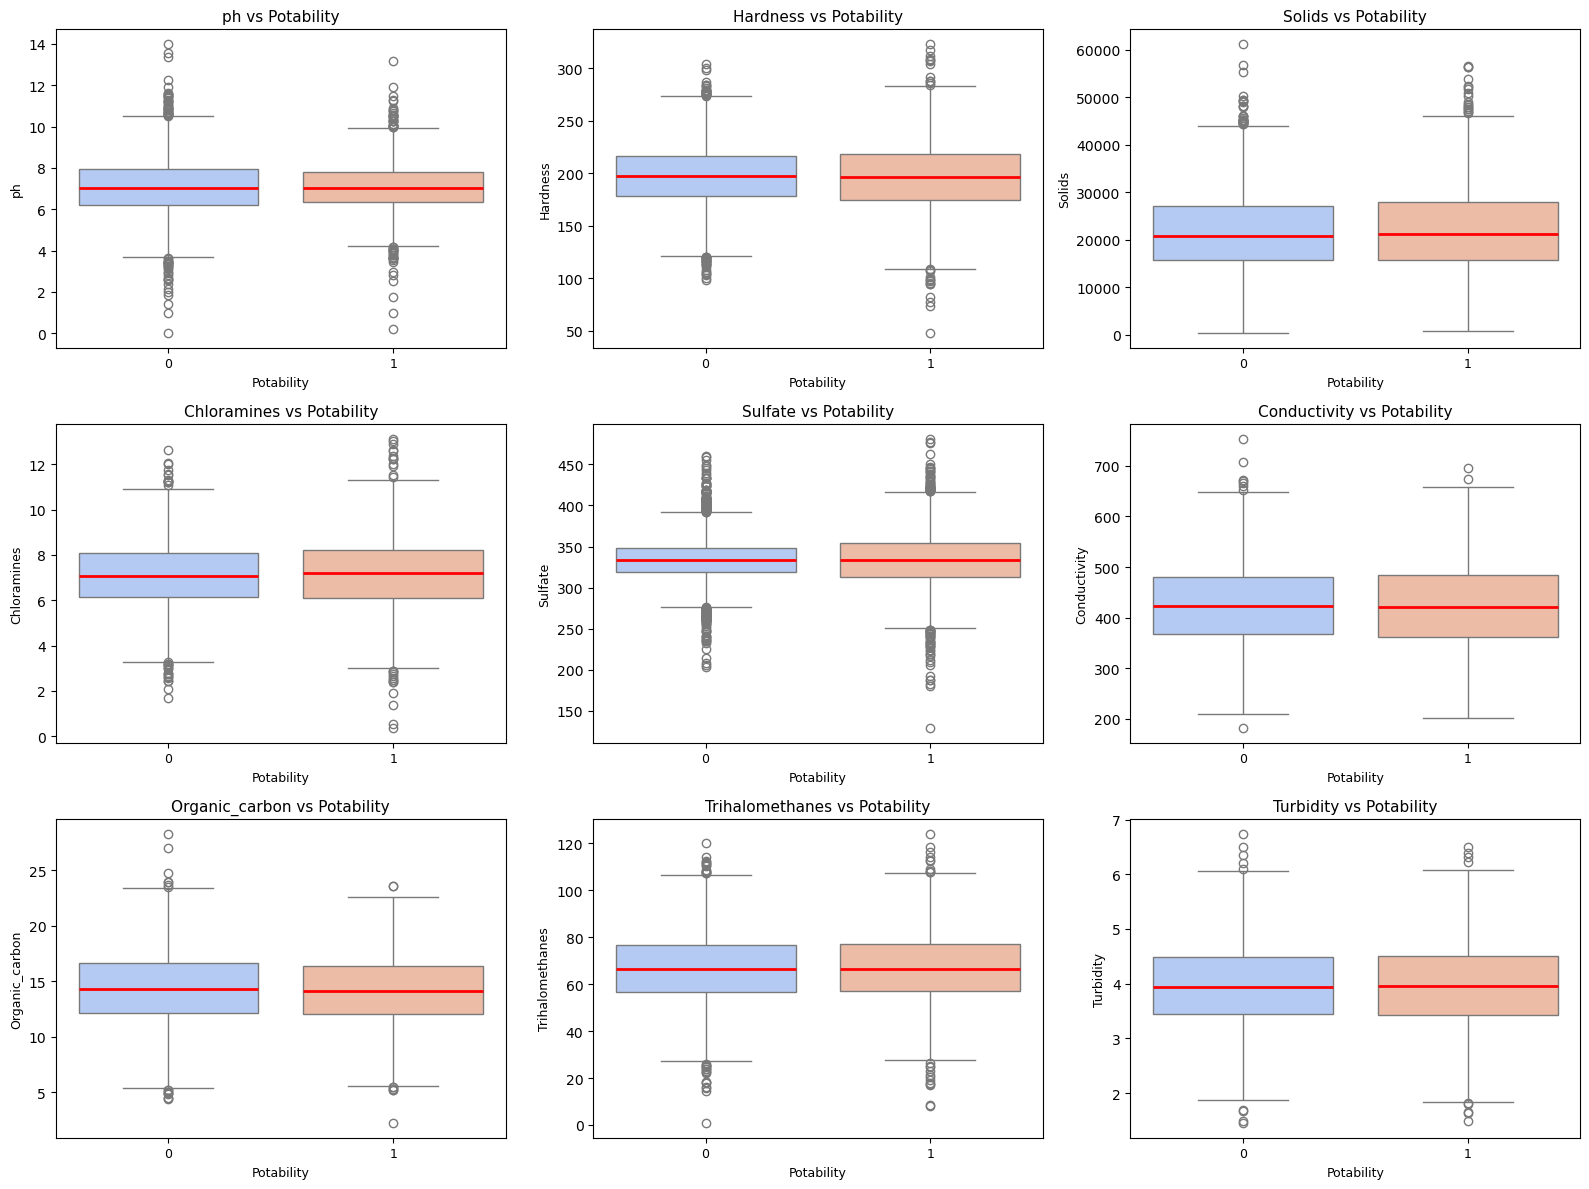

In [26]:
# Create figure and define layout
plt.figure(figsize=(16,12))

# Loop through each feature to generate boxplots against the target variable
for i, col in enumerate(features.columns, 1):
    # Define subplot position   
    plt.subplot(3, 3, i)
    # Create boxplot comparing feature distribution by Potability    
    sns.boxplot(x='Potability', y=col, data=water_imputation, hue='Potability', palette='coolwarm', dodge=False, legend=False, 
                medianprops=dict(color='red', linewidth=2))
    # Set plot title and labels    
    plt.title(f'{col} vs Potability', fontsize=11)
    plt.xlabel('Potability', fontsize=9)
    plt.ylabel(col, fontsize=9)
    plt.xticks(fontsize=9)
    
# Adjust layout for better spacing
plt.tight_layout()
# Display plots
plt.show()

The boxplot analysis shows a **strong overlap** between potable and non-potable water samples across most variables. This strong overlap means that the **median values** (central line in the box) and the **interquartile ranges** (the box itself, representing the middle 50% of the data) are very similar between both classes.<br>
In practical terms, this indicates that the same feature values can appear in both potable and non-potable water. For example, a given pH value may correspond to either classes, making it difficult to distinguish between them.<br>
If the boxplots were more separated (with different medians and less overlap), the feature would have better classification power. However, due to the overlap, individual variables are **not clearly distinguishable** between classes.<br>
Overall, water potability cannot be explained by a single variable and is instead influenced by the combined effect of multiple features.

### 7.3 Feature Engineering

Feature Engineering is a key step within **Data Preprocessing** that focuses on preparing and transforming variables to improve model performance and ensure compatibility with machine learning algorithms.

This process includes techniques such as:
<br>- **Feature Scaling**, to standardize numerical ranges.
<br>- **Feature Transformation**, to address skewness and distribution issues.
<br>- **Categorical Encoding**, to convert non-numerical variables into numerical format.
<br>- **Multicollinearity Assessment**, to identify redundacy among features.
<br>- **Feature Selection Decision**, to decide which variables to retain or remove for model training.

In this dataset, all variables represent **physically meaningful environmental parameters**, which are directly related to water quality assessment.

Based on the results obtained during the **EDA**:
<br>- The dataset does not exhibit strong linear relationships between variables
<br>- Correlation values are generally weak, indicating low redundancy among features
<br>- No clear patterns or interactions justify the creation of additional derived variables

In scenarios where strong relationships or interactions exist, new features can be created (e.g., ratios between variables, interaction terms or domain-based combinations) to better capture underlying patterns.<br>
However, in this case, such transformations are not justified. Therefore, **no new features are created**, and the original variables are retained.<br>

####  7.3.1 Feature Scaling Assessment

This step is applied to standardize the range of numerical variables, ensuring that all features contribute equally to machine learning models.<br>
The analysis of feature ranges shows that variables such as Solids exhibit significantly larger numerical magnitudes compared to other variables. For example, Solids ranges from approximately 320 to over 61,000, while variables such as pH and **Turbidity operate within much smaller ranges.<br>
These differences reflect natural measurement units; however, they can negatively affect the performance of certain machine learning algorithms.<br>
Models such as **Logistic Regression, K-Nearest Neighbors and Support Vector Machines are sensitive to feature scale**, as they rely on distance calculations or gradient optimization. In contrast, tree-based models such as **Random Forest and Gradient Boosting are not affected by scaling**.<br>
Common scaling techniques includes **Standardization (StandardScaler)** and **Normalization (MinMaxScaler)**.<br>
Feature Scaling is applied to all numerical variables to ensure consistency across the dataset.
The scaling process is performed after splitting the dataset into training and testing sets. The scaler is fitted on the training data and then applied to both training and test sets to prevent data leakage.<br>
Therefore, **Feature Scaling is applied** only to scale-sensitive models sure compatibility across all evaluated models. The specific scaling method is implemented during the **Data Preparation for Modelling** stage.

#### 7.3.2 Feature Transformation

This step refers to techniques used to modify the distribution (shape) of numerical variables, typically to reduce skewness and improve statistical properties.<br>
Common transformation techniques include **Logarithmic**, **Square Root** and **Box-Cox** transformations.<br>
In general, variables with **skewness values greater than 1 or lower than -1** are considered highly skewed and **may require transformation**.<br>
Based on the **Skewness Analysis** conducted during the **EDA** phase, most variables in the dataset exhibit approximately symmetric distributions, with skewness values close to zero.<br>
Although some variables, such as Solids, show moderate positive skewness, the magnitude is not sufficiently high to justify transformation.<br>
Therefore, **Feature Transformation is not applied** in this study, as the dataset does not exhibit strong asymmetry that would significantly impact model performance.

#### 7.3.3 Categorical Encoding

This process involves **converting categorical variables into numerical representations** so that they can be used in machine learning algorithms.<br>
Common encoding techniques include **One-Hot**, **Label** and **Ordinal** encoding methods, depending on the nature of the categorical data.<br>
Encoding is an essential **Data Preprocessing** step when working with datasets that contain non-numerical variables, as most machine learning models require numerical input.<br>
In this case, **Categorical Encoding is not applied**, as all variables in the dataset are already numerical and represent continuous physicochemical measurements.Therefore, no transformation of categorical data is required.

#### 7.3.4 Multicollinearity Assessment

While **Correlation Analysis** evaluates pairwise relationships between variables, it may not fully capture more complex dependencies involving multiple variables simultaneously.<br>
Therefore, **Multicollinearity** is further assessed using the **Variance Inflation Factor (VIF)**.<br>
Multicollinearity refers to a situation in which a variable can be partially explained by a combination of other variables in the dataset, indicating the presence of overlapping or redundant information among features.<br>
The **VIF** measures how strongly a feature is linearly associated with all other independent variables combined. Higher VIF values indicate greater redundancy and stronger multicollinearity among variables.<br>
Additionally, dimensionality reduction techniques such as **Principal Component Analysis (PCA)** are commonly considered when datasets exhibit excessive multicollinearity or a large number of highly correlated variables. PCA transforms the original variables into a smaller set of uncorrelated components while preserving most of the dataset variance.<br>
However, in this study, **PCA is not applied**. Although several variables exhibit high VIF values, preserving the interpretability and physical meaning of the original environmental parameters is considered more important for water quality assessment.

In [33]:
# Independent variables
X = water_imputation.drop(columns=['Potability'])
# Dependent variable
y = water_imputation['Potability']

# Create DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data["Parameter"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Display VIF results
vif_data

,Parameter,VIF
0,ph,22.809050
1,Hardness,30.836022
2,Solids,6.969571
3,Chloramines,19.585579
4,Sulfate,56.176186
5,Conductivity,25.978811
6,Organic_carbon,18.695406
7,Trihalomethanes,17.371757
8,Turbidity,24.128751


The interpretation of VIF values can be summarised as follows:

| VIF value | Interpretation |
|------------------------|----------------|
| ≈ 1 | No multicollinearity |
| 1 - 5 | Low to moderate multicollinearity |
| 5 - 10 | Moderate to high multicollinearity |
| > 10 | High multicollinearity (potential concern) |

The **VIF results** indicate that several variables exhibit relatively **high multicollinearity**, with VIF values greater than 10.<br>
This suggests that some features share overlapping information and may be partially explained by combinations of other variables. Only the variable **Solids** presents a comparatively **lower VIF** value (approximately 7), indicating moderate multicollinearity relative to the remaining features.<br>
Overall, the dataset exhibits a **notable degree of multicollinearity** which is expected in environmental datasets where physicochemical parameters are naturally interconnected through shared environmental processes.

#### 7.3.5 Feature Selection Decision

Despite the presence of relatively high multicollinearity indicated by the **VIF** analysis, **no features are removed** from the dataset.<br>
This behavior is common in environmental datasets, where physicochemical parameters are naturally interrelated and influenced by shared underlying processes. Therefore, a certain degree of multicollinearity is expected and does not necessarily indicate poor data quality.<br>
Removing variables solely based on **VIF** values could result in the loss of environmentally relevant information, particularly in datasets where multiple variables jointly describe complex water quality conditions.<br>
Furthermore, several machine learning models selected for this study, including **Random Forest (RF)** and **Gradient Boosting (GB)**, are relatively robust to multicollinearity due to their non-linear learning structure and ability to capture feature interactions.<br>
In contrast, models such as **Logistic Regression (LR)** and **K-Nearest Neighbors (KNN)** may be more sensitive to feature relationships and variable scaling. **Support Vector Machine (SVM)** can also be influenced by feature scaling and data struture, although they are generally less affected by multicollinearity than purely linear models.<br>
However, the primary objective of this study focuses on predictive performance and environmental interpretation rather than strict coefficient interpretability.<br>
Therefore, all original variables are retained for subsequent **Data Preparation for Modelling**.

## 8. Dataset Preparation For Modelling

Dataset Preparation for Modelling is a fundamental stage in the machine learning workflow, focused on preparing the dataset for model training and evaluation following the **Data Preprocessing** stage.<br>

In this study, the dataset preparation process consists of the following key steps:
<br>- **Features and Target Definition**, to separate predictor variables from the target variable used for classification.
<br>- **Train-Test Split**, to divide the dataset into training and testing subsets while preserving class distribution.
<br>- **Feature Scaling Application**, to standardize numerical feature ranges for scale-sensitive machine learning algorithms.
<br>- **Class Imbalance Assessment**, to evaluate the distribution of potable and non-potable water samples to modelling.

Overall, this stage ensures that the dataset is properly structured and ready for machine learning modelling.

### 8.1 Features and Target Definition

In supervised machine learning, the dataset is divided into **independent variables (features)** and the **dependent variable (target)**. The target variable represents the outcome to be predicted, while the features contain the input information used by the models.

In this study, the **variable Potability** is defined as the target variable, where:
<br>- **1** = Potable water
<br>- **0** = Non-potable water<br>

All remaining physicochemical parameters are used as **predictor variables (features)**.

In [6]:
# Define independent variables or features (X) 
X = water_imputation.drop(columns="Potability")

# Define dependent variable or target (y)
y = water_imputation["Potability"]

# Verify shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3276, 9)
y shape: (3276,)


The dataset is now separated into features (X) and the target variable (y). preparing it for the **Train-Test Split** stage and subsequent machine leaning modelling.

### 8.2 Class Imbalance Assessment

Class distribution analysis is performed to evaluate whether the target variable **exhibits imbalance between potable and non-potable** water classes.<br>
The distribution of the target classes is examined using both numerical summaries and graphical visualization. Understanding class proportions is important because highly imbalanced datasets may bias machine learning models toward the majority class.

In [39]:
# Create class distribution summary
class_summary = pd.DataFrame({'Count': y.value_counts(), 'Percentage (%)': y.value_counts(normalize=True)*100})

# Reorder rows manually
class_summary = class_summary.reindex([1, 0])

# Rename index labels
class_summary.index = ['Potable (1)', 'Non-potable (0)']

# Format percentages
class_summary['Percentage (%)'] = class_summary['Percentage (%)'].round(2)

# Display table
class_summary

,Count,Percentage (%)
Potable (1),1278,39.01
Non-potable (0),1998,60.99


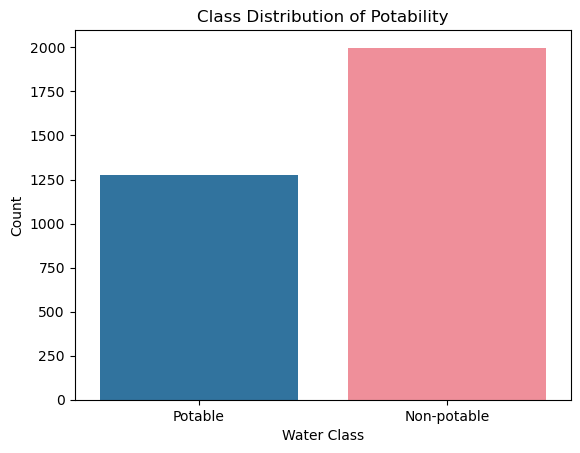

In [41]:
# Create count plot
sns.countplot(x=y.map({1: 'Potable', 0: 'Non-potable'}), order=['Potable', 'Non-potable'], palette=['#1f77b0', '#ff7f8e'])

# Set title
plt.title("Class Distribution of Potability")

# Set axis labels
plt.xlabel("Water Class")
plt.ylabel("Count")

# Show plot
plt.show()

Class imbalance severity can be interpreted as follows:

| Imbalance | Interpretation |
|------------------------|----------------|
| 50/50 | Perfect balance |
| 60/40 | Slight imbalance |
| 70/30 | Moderate imbalance |
| 80/20 | Severe imbalance |

The class distribution analysis shows that approximately **61%** of the samples correspond to **non-potable water**, while **39%** correspond to **potable water**.<br>
Based on the observed proportions, the dataset **exhibits a slight class imbalance**. However, the imbalance is not sufficiently severe to require corrective techniques such as resampling.<br>
In machine learning, **resampling techniques** are commonly applied when datasets exhibit moderate or severe class imbalance. These methods aim to improve class representation and reduce prediction bias toward the majority class.<br>

Common resampling approaches include:
<br>- **SMOTE (Synthetic Minority Oversampling Technique)**: generates synthetic samples for the minority class.
<br>- **Random Oversampling**: duplicates minority class observations.
<br>- **Random Undersampling**: reduces observations from the majority class.
<br>- **Class Weighting**: increases the penalty for misclassifying minority class samples during model training.

Since the observed imbalance in this dataset is relatively slight, **no resampling techniques are applied** at this stage.

### 8.3 Train-Test Split

To evaluate model performance objectively, the dataset is divided into **80% training** and **20% testing** subsets. The training set is used to train the machine learning models, while the testing set is reserved for evaluating model generalization on unseen data.<br>
To further verify the consistency of the stratified split, the number of potable and non-potable samples within the training and testing datasets is also examined. 

In [42]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create class distribution summary
split_summary = pd.DataFrame({ 'Training Set': y_train.value_counts(normalize=True), 'Testing Set': y_test.value_counts(normalize=True)})

# Reorder rows manually
split_summary = split_summary.reindex([1, 0])

# Rename index labels
split_summary.index = ['Potable (1)', 'Non-potable (0)']

# Display table
split_summary

,Training Set,Testing Set
Potable (1),0.390076,0.390244
Non-potable (0),0.609924,0.609756


The dataset was successfully divided into **80% training** data and **20% testing** data while **preserving the original class distribution of the target** variable. This ensures consistent representation of potable and non-potable water samples across both datasets.<br>
**Stratified splitting was applied using stratify=y** to mantain consistent porportions of potable and non-potable water samples across both datasets.

In [47]:
# Create class distribution summary for training and testing sets
train_test_distribution = pd.DataFrame({'Training Set': y_train.value_counts(), 'Testing Set': y_test.value_counts()})

# Reorder rows manually
train_test_distribution = train_test_distribution.reindex([1, 0])

# Rename index labels
train_test_distribution.index = ['Potable (1)', 'Non-potable (0)']

# Display class distribution table
train_test_distribution

,Training Set,Testing Set
Potable (1),1022,256
Non-potable (0),1598,400


The table above shows the numerical distribution of potable and non-potable water samples within the training and testing datasets. The proportions remain approximately consistent across both subsets due to the application of **stratified sampling** during the train-test split process.

### 8.4 Feature Scaling Application 

Feature Scaling is applied after the **Train-Test Split** using **StandardScaler**.<br>
The scaler is fitted exclusively on the training data and then applied to both the training and testing sets using the same scaling parameters. This approach prevents data leakage and ensures consistency between datasets.<br>
Scaling is particularly important for scale-sensitive algorithms such as **Logistic Regression (LR), K-Nearest Neighbors (KNN) and Support Vector Machine (SVM)**.

In [8]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler only on training data and transform trainig set
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling transformation to testing set
X_test_scaled = scaler.transform(X_test)

The scaling process was successfully completed, producing standardized training and testing datasets for subsequent machine learning modelling.<br>
The transformed datasets are now suitable for scale-sensitive algorithms, while maintaining methodological consistency and preventing information leakage between subsets.

## 9. Model Selection and Training

In [ ]:
agregar algo al final

### 9.1 Model Selection Rationale

The selection of machine learning models in this study aims to compare different classification approaches for water potability prediction using models with varying learning strategies and complexity levels.

Five classification models are evaluated in this study:
<br> - **Logistic Regression (LR)**, representing a linear baseline classification model,
<br> - **K-Nearest Neighbors (KNN)**, representing a distance-based classification model,
<br> - **Support Vector Machine (SVM)**, representing a margin-based classication model,
<br> - **Random Forest (RF)**, representing a tree-based ensemble classification model,
<br> - **Gradient Boosting (GB)**, representing a sequential tree-based ensemble classification model.

Environmental datasets often exhibit non-linear relationships, multicollinearity, variable interactions and heterogeneous data distributions. Therefore, ensemble and non-linear models such as **RF, GB and SVM are expected to better capture complex patterns** within the dataset.<br>
However, simpler models such as **LR and KNN are also included to provide baseline references** and allow performance comparison between linear, distance-based and ensemble learning approaches.<br>
Additionally, previous exploratory analysis identified moderate skewness, multicollinearity and variable scale differences among features. As a result, feature scaling is applied for scale-sensitive models such as LR, KNN and SVM, while tree-based models are trained using the original feature scales.

### 9.2 Logistic Regression (LR)

Logistic Regression (LR) is a supervised linear classification algorithm commonly used as a baseline model due to its simplicity, interpretability and computational efficiency.<br>
LR generally performs better when predictor variable are properly scaled and when relationships within the dataset are relatively simple. Since **LR is sensitive to feature magnitude differences**, standardized features are used during model training.<br>
In this study, LR is included as a baseline reference model to compare its performance with more advanced machine learning approaches.

In [16]:
# Initialize LR model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

LR is implemented as a linear classification model that estimates the relationship between water quality features and potability outcomes. Its simplicity and interpretability make it useful as a baseline reference for comparison with more complex machine learning models.

### 9.3 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised distance-based classification algorithm that classifies observations based on similarities between neighboring samples in feature space.<br>
**KNN performs better when features are properly scaled**, since distance calculations are sensitive to variable magnitude differences. Therefore, standardized features are used during model training.<br>
In this study, KNN is included to evaluate the ability of distance-based learning to capture local similarities and patterns within the water quality dataset.

In [11]:
# Initialize KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_knn = knn_model.predict(X_test_scaled)

KNN is implemented as a distance-based classification model that predicts class membership according to similarities between neighbouring observations in feature space. The model captures local patterns in the dataset by comparing observations with similar physicochemical characteristics.

### 9.4 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised margin-based classification algorithm designed to separate classes by identifying an optimal boundary between catogories.<br>
**SVM performs well in datasets with complex relationships** and is particularly useful when classes are not easily separated using simple linear methods. Since **SVM is sensitive to feature magnitude differences**, standardised features are used during model training.<br>
In this study, SVM is included to evaluate the ability of advanced classification boundaries to distinguish potable from non-potable water samples.

In [12]:
# Initialize SVM model
svm_model = SVC(probability=True, random_state=42)   # Enable probability estimates for ROC-AUC (predict_proba())

# Train model
svm_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_svm = svm_model.predict(X_test_scaled)

SVM is implemented as a margin-based classification model that attempts to maximise class separation using an optimal decision boundary. This approach allows the model to handle complex relationships within the water quality dataset.

### 9.5 Random Forest (RF)

Random Forest (RF) is a supervised tree-based ensemble classification algorithm that combines multiple decision trees to improve classification performance and reduce overfitting.<br>
**RF performs well in datasets with complex and non-linear relationships**, as it can capture interactions between variables without requiring linear assumptions. Unlike distance-based and linear models, **RF is not sensitive to feature magnitude differences**, therefore feature scaling is not required during model training.<br>
In this study, RF is included to evaluate the ability of ensemble learning to improve the classification of potable and non-potable water samples through combined decision-tree predictions.

In [13]:
# Initialize RF model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

RF is implemented as an ensemble learning model that combines multiple decision trees to improve classification stability and reduce overfitting. Its tree-based structure allows the model to capture complex variable interactions within the dataset.

### 9.6 Gradient Boosting (GB)

Gradient Boosting (GB) is a supervised tree-based ensemble classification algorithm that builds decision trees sequentially to improve prediction performance.<br>
Unlike RF, where trees are created independently, **GB trains each new tree to correct errors made by previous trees**. This approach is effective for capturing complex and non-linear relationships within the dataset.<br>
**GB is not sensitive to feature magnitude differences**, since tree-based models do not rely on distance calculations or gradient-based feature scaling. Therefore, standardised features are not required during model training.<br>
In this study, GB is included to evaluate whether sequential ensemble learning can improve water potability classification performance.

In [14]:
# Initialize GB model
gb_model = GradientBoostingClassifier(random_state=42)

# Train model
gb_model.fit(X_train, y_train)

# Generate predictions
y_pred_gb = gb_model.predict(X_test)

GB is implemented as a sequential ensemble learning model in which each decision tree attempts to reduce the errors generated by previous trees. This iterative learning process allows the model to capture complex patterns and improve predictive performance in water quality classification tasks.

### 9.7 Initial Model Comparison

After training the machine learning models, an initial performance evaluation is conducted to assess how accurately each model classifies potable and non-potable water samples.<br>
Several evaluation metrics are used, including **Accuracy, Classification Reports and Confusion Matrices**. These metrics help measure overall prediction performance, identify classification errors and compare the strengths and limitations of each model.<br>
This initial comparison provides a general understanding of model behaviour before performing more advanced evaluation and optimisation procedures, such as **ROC Curve Analysis, AUC Evaluation, Overfitting Assessment, Cross-Validation and Hyperparameter Tuning**.

#### 9.7.1 Accuracy

Accuracy is used as an initial evaluation metric to measure the proportion of correctly classified observations within the test dataset. In binary classification problems, where observations are classified into two categories **(1 = potable and 0 = non-potable)**, accuracy represents the ratio of correct predictions relative to the total number of observations.<br> 
Although accuracy provides a general overview of model performance, it may not fully reflect classification quality when class imbalance or critical prediction errors are present.

In [23]:
# Store model accuracy scores
accuracy_results = {"Logistic Regression (LR)": accuracy_score(y_test, y_pred_lr), "K-Nearest Neighbors (KNN)": accuracy_score(y_test, y_pred_knn), 
                    "Support Vector Machine (SVM)": accuracy_score(y_test, y_pred_svm), "Random Forest (RF)": accuracy_score(y_test, y_pred_rf), 
                    "Gradient Boosting (GB)": accuracy_score(y_test, y_pred_gb)}

# Convert results to DataFrame and sort by accuracy
accuracy_df = pd.DataFrame(accuracy_results.items(), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

# Display sorted acuracy results
accuracy_df.style.hide(axis='index').format({'Accuracy': '{:.4f}'})

Model,Accuracy
Support Vector Machine (SVM),0.6707
Random Forest (RF),0.6585
Gradient Boosting (GB),0.6524
K-Nearest Neighbors (KNN),0.6143
Logistic Regression (LR),0.6098


Accuracy performance can be generally interpreted as follows:

| Accuracy Range | Interpretation |
|----------------|----------------|
| 0.50           | Random-level performance |
| 0.60 – 0.70    | Moderate performance |
| 0.80 - 0.90    | Strong performance |
| 0.90 - 1.00    | Excellent performance |

In this study, SVM achieved the highest overall accuracy (67.07%), meaning that approximately 67 out of every 100 test observations were correctly classified.<br>
RF and GB followed closely, while KNN and LR showed slightly lower predictive performance.

#### 9.7.2 Classification Reports  

Classification Reports are used to provide a more detailed evaluation of classification performance beyond overall accuracy. In binary classification problems, these reports summarise key metrics such as **Precision, Recall and F1-score** for each class, together with **Support** values and aggregated measures inclluding **Macro Average and Weighted Average** .<br>

- **Precision** indicates how reliable the model is when predicting a specific class. It answers the question: “When the model predicts a class, how often is it correct?”<br>
- **Recall** indicates how effectively the model detects the actual samples of a class. It answers the question: “Out of all real samples belonging to a class, how many were correctly identified?”.<br>
- **F1-score** provides a balanced measure between **Precision and Recall** and is especially useful when both detection capability and prediction reliability are important. It is calculated as:<br>
F1-score = 2 × (Precision × Recall) / (Precision + Recall).<br>
- **Support** represents the total number of actual observations belonging to each class within the test dataset.
- **Macro Average** computes the simple average of the evaluation metrics across all classes, treating each class equally.
- **Weighted Average** computes the average of the evaluation metrics weighted according to the number of samples in each class.

In water potability prediction, **particular attention must be given to potable water detection (class 1)**, as classification errors may have important environmental and public health implications. Therefore, classification reports provide more meaningful insights than accuracy alone when evaluating model reliability.

In [50]:
# Create separator line for better report visualization
separator = "\n" + "="*55 

# Display LR Classification Report
print(separator)
print("Logistic Regression (LR) Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Display KNN Classification Report
print(separator)
print("K-Nearest Neighbors (KNN) Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

# Display SVM Classification Report
print(separator)
print("Support Vector Machine (SVM) Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# Display RF Classification Report
print(separator)
print("Random Forst (RF) Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Display GB Classification Report
print(separator)
print("Gradient Boosting (GB) Report:\n")
print(classification_report(y_test, y_pred_gb))

# Display final separator
print(separator)


Logistic Regression (LR) Classification Report:

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


K-Nearest Neighbors (KNN) Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.80      0.72       400
           1       0.51      0.32      0.39       256

    accuracy                           0.61       656
   macro avg       0.58      0.56      0.56       656
weighted avg       0.59      0.61      0.59       656


Support Vector Machine (SVM) Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy               

In this study, particular attention is given to the **potable water class (class 1)**, as misclassifying contaminated water as potable may represent a serious environmental and public health risk. Therefore, evaluation should not rely solely on overall accuracy but also consider **Precision, Recall, and F1-score for class 1**.<br>

- **LR model** fails to correctly identify potable water samples, predicting all observations as non-potable. As a result, **Precision, Recall and F1-score for class 1 are equal to zero**. Although the model achieves an accuracy of 61% due to correct classification of non-potable water, it is **unsuitable for practical potable water prediction**.<br>
- **KNN model** demonstrates moderate capability for detecting potable water samples, correctly idetifying 32% of actual potable observations. Although precision reaches 51%, the relatively low recall indicates that **many potable samples are still misclassified as non-potable**.<br>
- **SVM model** achieves the highest precision for potable water (70%), indicating that predictions labeled as potable are usually corect. However, recall remaines low (27%), meaning that **many actual potable samples are not detected**.<br>
- **RF model** produces the highest F1-score for potable water classification (0.41), indicating the most balanced trade-off between precision and recall among the evaluated models. Although recall remaines moderate, this model **provides the most balanced performance for potable water detection**.<br>
- **GB model** showes behavior **similar to RF** but with slightly lower recall for potable water samples.<br>

Overall, **although SVM achieves the highest Precision and overall Accuracy, RF demonstrates the most balanced classification performance for potable water detection**. Considering the environmental and public health implications of water potability prediction, RF appears to provide the most reliable overall performance among the evaluated models.

#### 9.7.3 Confusion Matrices 

Confusion Matrices are used to provide a detailed visual representation of classification performance by comparing actual and predicted class labels. In binary classification problems, confusion matrices allow the identification of correctly and incorrectly classified observations for each class.

The confusion matrix is composed of four key components:
<br>- **True Positives (TP)**: potable water samples correctly classified as potable.
<br>- **True Negatives (TN)**: non-potable water samples correctly classified as non-potable.
<br>- **False Positives (FP)**: non-potable water samples incorrectly classified as potable (critical error).
<br>- **False Negatives (FN)**: potable water samples incorrectly classified as non-potable (error).

In water potability prediction, FP and FN are particularly important because classification errors may have environmental and public health implications. A FP may incorrectly identify contaminated water as safe for consumption, while a FN may incorrectly reject potable water samples.<br>
Therefore, Confusion Matrices provide deeper insight into model behavior beyond overall accuracy by showing how each model handles potable and non-potable water classification.

In [51]:
# Create separator line for better report visualization
separator = "\n" + "="*50

# Display LR Confusion Matrix
print(separator)
print("Logistic Regression (LR) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

# Display KNN Confusion Matrix
print(separator)
print("K-Nearest Neighbors (KNN) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_knn))

# Display SVM Confusion Matrix
print(separator)
print("Support Vector Machine (SVM) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

# Display RF Confusion Matrix
print(separator)
print("Random Forest (RF) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

# Display GB Confusion Matrix
print(separator)
print("Gradient Boosting (GB) Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))

# Display final separator
print(separator)


Logistic Regression (LR) Confusion Matrix:

[[400   0]
 [256   0]]

K-Nearest Neighbors (KNN) Confusion Matrix:

[[321  79]
 [174  82]]

Support Vector Machine (SVM) Confusion Matrix:

[[371  29]
 [187  69]]

Random Forest (RF) Confusion Matrix:

[[355  45]
 [179  77]]

Gradient Boosting (GB) Confusion Matrix:

[[365  35]
 [193  63]]



The Confusion Matrix structure used in this study is represented as follows:

| Actual Class | Non-potable | Potable |
|--------------|--------------|----------|
| Non-potable  |    [[TN        |   FP]     |
| Potable      |    [FN        |   TP]]     |

The Confusion Matrices confirm the patterns observed in the Classification Reports.
<br> - **LR model** predicts all observations as non-potable, resulting in zero TP and zero FP. Although this avoids critical false potable predictions, the model completely **fails to identify potable water samples**, making it unsuitable for practical potable water classification.
<br>- **KNN model** detects a higher number of potable samples compared to LR, but also produces the largest number of FP (79), indicating a greater tendency to **incorrectly classify contaminated water as potable**.
<br>- **SVM model** achieves the lowest number of FP (29) among the evaluated models, indicating more reliable potable predictions. However, the relatively high number of FN shows that many actual potable samples are still not detected.
<br>- **RF model** demonstrates the most balanced Confusion Matrix overall, maintaining relatively low FP while achieving a higher number of correctly identified potable samples compared to most other models.
<br>- **GB model** shows performance **similar to RF**, although with slightly fewer correctly detected potable samples and a higher number of FN.

Overall, the Confusion Matrices reinforce that **RF provides the most balanced classification performance for water potability prediction**, while SVM offers the safest potable predictions due to its lower FP rate.

## 10. Model Evaluation and Comparison
## 10. Model Evaluation and Performance Analysis

### 10.1 Confusion Matrix Analysis

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [("SVM", y_pred_svm), ("Random Forest", y_pred_rf), ("Logistic Regression", y_pred_log), ("KNN", y_pred_knn), ("Gradient Boosting", y_pred_gb)]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()

# Calculate Confusion Matrices
for i, (name, y_pred) in enumerate(models):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[i], colorbar=False)
    axes[i].set_title(f"{name} Confusion Matrix")

# Turn off the last empty space
axes[len(models)].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
models = [("SVM", y_pred_svm, "Oranges"), ("Random Forest", y_pred_rf, "Greens"), ("Logistic Regression", y_pred_log, "Blues"),
    ("KNN", y_pred_knn, "Purples"), ("Gradient Boosting", y_pred_gb, "Reds")]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()

for i, (name, y_pred, cmap) in enumerate(models):
    
    # Generate Confusion Matrices
    cm = confusion_matrix(y_test, y_pred)
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=axes[i], cbar=False)
    
    axes[i].set_title(f"{name}\nAccuracy: {acc:.2f}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Turn off empty spaces
for ax in axes[len(models):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### The confusion matrices provide a direct numerical comparison of classification performance across all evaluated models.
#### KNN achieved the highest number of correctly detected potable water samples (82 true positives), followed by Random Forest (77) and SVM (69). 
#### However, KNN also produced the highest number of contaminated water samples incorrectly classified as potable (79 false positives), indicating a significantly higher public health risk.
#### Logistic Regression generated the lowest number of false positives (0). Nevertheless, it completely failed to detect potable water (0 true positives), classifying all samples as non-potable. Although it avoids critical contamination errors, it lacks practical predictive capability.
#### Among the functional models, SVM produced the lowest number of false positives (29), followed by Gradient Boosting (35) and Random Forest (45). This suggests that SVM provides stronger control over critical contamination misclassification errors.
#### Random Forest presents a trade-off: it detects more potable samples (77 true positives) than SVM (69 true positives), but at the cost of increasing contamination risk (45 false positives vs 29 for SVM).
#### Gradient Boosting demonstrates intermediate behavior, with moderate potable detection (63 true positives) and controlled contamination misclassification (35 false positives).
#### Overall, the confusion matrix analysis highlights a structural trade-off between potable detection capability (true positives) and contamination misclassification risk (false positives). Model selection therefore depends on whether maximizing potable detection or minimizing critical contamination errors is prioritized in the environmental decision context.

### 10.2 Accuracy Discussion

In [ ]:
print("SVM Accuracy (Test):", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy (Test):", accuracy_score(y_test, y_pred_rf))
print("GB Accuracy (Test):", accuracy_score(y_test, y_pred_gb))
print("KNN Accuracy (Test):", accuracy_score(y_test, y_pred_knn))
print("LR Accuracy (Test):", accuracy_score(y_test, y_pred_log))

#### Accuracy represents the proportion of correctly classified observations in the test dataset. For example, an accuracy of 0.67 indicates that 67% of the predictions match the actual values in the test set.
#### However, accuracy alone may be misleading in classification problems where class distribution is uneven or where certain types of errors carry greater consequences.
#### In this study, SVM achieved the highest overall accuracy (0.6707), followed closely by Random Forest (0.6585) and Gradient Boosting (0.6524). Although the numerical differences are small (1%), SVM appears slightly superior when considering total correct classification performance. KNN (0.6143) and Logistic Regression (0.6097) showed lower overall predictive accuracy.
#### Nevertheless, the confusion matrix analysis revealed that higher accuracy does not necessarily correspond to better potable water detection or lower critical misclassification rates. Therefore, accuracy should be interpreted alongside precision, recall, and false positive rates to ensure a meaningful environmental risk assessment.

### 10.3 Precision, Recall, F1-score Analysis

In [ ]:
models = {"SVM": y_pred_svm, "RF": y_pred_rf, "LR": y_pred_log, "KNN": y_pred_knn, "GB": y_pred_gb}
metrics_data = []

for name, y_pred in models.items():
    
    report = classification_report(y_test, y_pred, output_dict=True)  
    metrics_data.append({
        "Model": name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"]
    })

df_metrics = pd.DataFrame(metrics_data).set_index("Model")

In [ ]:
ax = df_metrics.plot(kind="bar", figsize=(10,6), width=0.8)

plt.title("Precision, Recall and F1-Score (Class 1 - Potable)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

#### Precision indicates how reliable the model is when predicting a specific class. In this context, it measures how many samples predicted as potable were actually potable.
#### Recall indicates how many actual samples of a class were correctly identified. For potable water (class 1), recall measures how many truly potable samples were successfully detected by the model.
#### F1-score provides a balanced metric between precision and recall. It is particularly useful when there is a trade-off between detecting more potable samples and minimizing critical misclassification errors.
#### Although SVM achieved the highest overall accuracy in the previous evaluation, Random Forest demonstrates the best balance between precision and recall for potable water detection (F1-score = 0.41 for class 1). SVM and Gradient Boosting show slightly lower but comparable F1-scores, while KNN presents moderate performance.#### Logistic Regression is unsuitable for this application because it fails entirely to detect potable samples (recall = 0 for class 1), resulting in an F1-score of 0.
#### From an environmental and public health perspective, recall for potable water remains a critical metric, since failing to correctly identify safe water reduces the model’s practical usability. However, none of the evaluated models achieve high recall for potable water, suggesting that further model optimization, threshold tuning, or class balancing strategies may be required.

### 10.4 Receiver Operating Characteristic (ROC Curve) & Area Under de Curve (AUC Score)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

models = [("SVM", svm_model, X_test), ("Random Forest", rf_model, X_test), ("Logistic Regression", log_model, X_test_scaled),
    ("KNN", knn_model, X_test_scaled), ("Gradient Boosting", gb_model, X_test)] # SVM (need probability=True in the model)

plt.figure(figsize=(8,6))

for name, model, X_data in models:
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob) 
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

#### AUC interpretation
#### 0.5 → random classification
#### 0.7 → acceptable discrimination
#### 0.8 → good discrimination
#### 0.9 → excellent discrimination
#### 1.0 → perfect separation

#### The ROC curve evaluates the global discriminative ability of each model across all possible classification thresholds. While accuracy depends on a fixed threshold (commonly 0.5), the ROC curve assesses how well the model separates classes regardless of the chosen cutoff. 
#### In this study, Random Forest achieved the highest AUC (0.64), followed closely by Gradient Boosting (0.63), indicating moderate class separation capability.These values suggest that both models possess some ability to rank potable samples higher than non-potable ones, although performance remains far from optimal.
#### SVM obtained an AUC of 0.50, suggesting performance equivalent to random classification in terms of probability ranking.
#### Although SVM achieved slightly higher accuracy and fewer false positives, its inability to effectively separate classes across thresholds indicates limited structural discrimination capacity. This indicates that, although SVM achieved slightly higher accuracy and fewer false positives under the fixed threshold evaluation, it lacks structural discrimination capacity when evaluated across all thresholds.
#### Random Forest, despite producing slightly more false positives in the confucion matrix analysis, demonstrates stronger global separation between potable and non-potable samples.
#### Therefore, when considering both fixed-threshold performance (accuracy and confusion matrix) and global discrimination ability (AUC), Random Forest emerges as the more robust and reliable model for this dataset.

### 10.5 Model Comparison & Integrated Evaluation

In [ ]:
models = {"SVM": (svm_model, y_pred_svm, X_test), "Random Forest": (rf_model, y_pred_rf, X_test), "Gradient Boosting": (gb_model, y_pred_gb, X_test),
    "KNN": (knn_model, y_pred_knn, X_test_scaled), "Logistic Regression": (log_model, y_pred_log, X_test_scaled)}

comparison_data = []

for name, (model, y_pred, X_data) in models.items(): 
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)   
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    # AUC
    y_prob = model.predict_proba(X_data)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    
    comparison_data.append({"Model": name, "Accuracy": acc, "AUC": auc_score, "True Positives (TP)": tp, "False Positives (FP)": fp,
        "Recall (Class 1)": report["1"]["recall"], "F1-Score (Class 1)": report["1"]["f1-score"]})

comparison_table = pd.DataFrame(comparison_data).sort_values(by="F1-Score (Class 1)", ascending=False)
comparison_table

In [ ]:
summary_data = {"Metric": ["Highest Accuracy", "Highest AUC", "Highest True Positives (TP)", "Lowest False Positives (FP)",
                "Lowest False Positives (Functional Model)", "Best Recall (Class 1)", "Best F1-Score (Class 1)"],
                "Best Model": ["SVM", "Random Forest", "KNN", "Logistic Regression", "SVM", "KNN", "Random Forest"], 
                "Value": [0.67, 0.64, 82, 0, 29, 0.32, 0.41]}
df_summary = pd.DataFrame(summary_data)
df_summary

#### The integrated comparison table highlights clear performance differences across evaluation criteria.
#### SVM achieved the highest overall accuracy (0.67) and the lowest number of false positives among functional models (29), indicating strong control over contamination misclassification under a fixed threshold.
#### Random Forest achieved the highest AUC (0.64), suggesting superior global class separation capability. It also obtained the highest F1-score for potable water detection (0.41), indicating the best balance between precision and recall for class 1.
#### KNN demonstrated the highest number of correctly detected potable samples (82 true positives) and the highest recall for potable water (0.32). However, it also produced the highest number of false positives (79), representing a substantial contamination misclassification risk.
#### Gradient Boosting showed consistent intermediate performance across most metrics, with moderate AUC (0.63) and controlled false positive rates (35).
#### Logistic Regression failed to detect potable water entirely and is therefore unsuitable for this application despite generating zero false positives.
#### When integrating all performance indicators — fixed-threshold accuracy, critical error control (false positives), potable detection capability (recall and true positives), F1-score balance, and global discrimination ability (AUC) — Random Forest demonstrates the most structurally balanced and robust performance for this dataset.
#### Although SVM performs well under fixed-threshold evaluation, its AUC of 0.50 suggests limited discrimination capability beyond the selected threshold.
#### Therefore, Random Forest is selected as the most appropriate model for further validation and generalization assessment.

### 10.6 Overfitting Assessment

In [ ]:
models_train_test = {"Logistic Regression": (log_model, X_train_scaled, X_test_scaled), "SVM": (svm_model, X_train_scaled, X_test_scaled), 
                     "KNN": (knn_model, X_train_scaled, X_test_scaled), "Random Forest": (rf_model, X_train, X_test), 
                     "Gradient Boosting": (gb_model, X_train, X_test)}

results = []

for name, (model, X_tr, X_te) in models_train_test.items():
    train_acc = model.score(X_tr, y_train)
    test_acc = model.score(X_te, y_test)
    results.append({"Model": name, "Train Accuracy": train_acc, "Test Accuracy": test_acc, "Gap (Train - Test)": train_acc - test_acc})

df_train_test = pd.DataFrame(results).set_index("Model").round(4)
df_train_test

#### 0.70 → good (depends on the problem)
#### 0.60–0.70 → moderate
#### < 0.60 → low
#### ≈ 0.50 → almost random in binary

#### Train ≈ Test (both reasonably high) -> The model learns generalizable patterns and does not memorize the training data. This represents good generalization and a well-fitted model.
#### Train = Test low (both reasonably low) -> The model is too simple and fails to capture meaningful patterns (underfitting).
#### Train >> Test -> The model memorizes the training data (overfitting). The larger the gap between training and testing performance, the more severe the overfitting.

#### To evaluate generalization capacity, training and testing accuracy were compared across all evaluated models.
#### Logistic Regression shows nearly identical training (0.6099) and testing accuracy (0.6098), indicating stable but limited predictive capacity. The low performance in both datasets suggests mild underfitting rather than overfitting.
#### SVM presents good generalization behavior, with training accuracy of 0.7382 and testing accuracy of 0.6707 (gap ≈ 0.067). The relatively small difference indicates acceptable stability and limited overfitting.
#### Gradient Boosting demonstrates moderate generalization with a training accuracy of 0.7420 and testing accuracy of 0.6524 (gap ≈ 0.089). Although some overfitting is present, it remains within acceptable limits.
#### KNN exhibits stronger overfitting tendencies, with a training accuracy of 0.7614 and testing accuracy of 0.6143 (gap ≈ 0.147). The larger discrepancy suggests that the model captures training patterns more aggressively, reducing generalization performance.
#### Random Forest shows severe overfitting, achieving perfect training accuracy (1.00) but considerably lower testing accuracy (0.6585). The substantial gap (≈ 0.34) indicates that the model memorizes the training data rather than learning generalizable patterns.
#### Overall, SVM and Gradient Boosting demonstrate the most stable generalization behavior, while Random Forest requires hyperparameter tuning to reduce model complexity and improve generalization capacity.

### 10.7 Final Model Selection

#### GB -> intermediate balance (intermediate candidate)
#### RF -> better AUC but worse generalization (powerful but with high overfitting)
#### SVM -> better stability but low AUC (stable but structurally weak)

#### Based on the integrated evaluation of accuracy, confusion matrices, AUC performance, and overfitting assessment, model selection must balance predictive strength and generalization stability.
#### Random Forest achieved the highest AUC but exhibited severe overfitting, indicating memorization of training data. While powerful, its generalization stability is limited without further regularization.
#### SVM demonstrated strong stability and the highest fixed-threshold accuracy. However, its AUC of 0.50 suggests weak structural discrimination capacity, limiting its robustness across classification thresholds.
#### Gradient Boosting presents the most balanced performance profile. It achieves competitive AUC (0.63), moderate overfitting, and stable generalization behavior without extreme memorization effects.
#### Therefore, Gradient Boosting is selected as the primary candidate for further hyperparameter optimization. Random Forest remains a secondary candidate due to its strong discriminative potential if properly regularized. SVM may be considered for exploratory tuning but is not prioritized given its limited AUC performance.

## 11 Model Optimization

### 11.1 Hyperparameter Tuning (Gradient Boosting)

#### 11.1.1 Hyperparameter selection strategy

#### A grid search strategy was implemented to optimize Gradient Boosting performance. The parameter ranges were selected to balance model complexity and generalization capacity.
#### Five-fold cross-validation (cv=5) was applied to ensure robust evaluation across different data splits. The scoring metric was set to F1-score to prioritize balanced performance for potable water detection.
#### n_estimators [100, 200]: controls the number of boosting stages. Higher values increase model capacity but may increase overfitting. 100–200 was selected as a moderate search range.
#### learning_rate [0.01, 0.05, 0.1]: determines how strongly each tree contributes. Lower learning rates improve stability but require more trees. Tested moderate values to balance convergence and generalization.
#### max_depth [3, 4, 5]: limits tree complexity. Smaller depth reduces overfitting. Values kept relatively shallow to control model variance.
#### min_samples_split / min_samples_leaf: prevent trees from splitting too aggressively. Help regularize the model and improve generalization.

#### 12.1.2) Best hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define parameter grid
param_grid_gb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 4, 5], 
                 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}

gb = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb, cv=5, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)

# Best model
best_gb = grid_gb.best_estimator_

print("Best GB Parameters:", grid_gb.best_params_)

#### The optimized configuration increased the number of estimators while maintaining moderate tree depth.
#### This suggests that model performance benefits from a higher ensemble size rather than deeper trees.exity.


#### 12.1.3) Optimized performance

In [ ]:
y_pred_gb_opt = best_gb.predict(X_test)
print("Optimized GB Accuracy:", accuracy_score(y_test, y_pred_gb_opt))

In [ ]:
y_pred_gb_opt = best_gb.predict(X_test)
print(classification_report(y_test, y_pred_gb_opt))

In [ ]:
y_prob_gb_opt = best_gb.predict_proba(X_test)[:,1]
auc_gb_opt = roc_auc_score(y_test, y_prob_gb_opt)

print("Optimized GB AUC:", auc_gb_opt)

In [ ]:
# BASE MODEL METRICS 

# Accuracy base
acc_base = accuracy_score(y_test, y_pred_gb)
# Classification report base
report_base = classification_report(y_test, y_pred_gb, output_dict=True)
precision_base = report_base["1"]["precision"]
recall_base = report_base["1"]["recall"]
f1_base = report_base["1"]["f1-score"]
# AUC base
y_prob_base = gb_model.predict_proba(X_test)[:,1]
auc_base = roc_auc_score(y_test, y_prob_base)

# OPTIMIZED MODEL METRICS

# Accuracy optimized
acc_opt = accuracy_score(y_test, y_pred_gb_opt)
# Classification report optimized
report_opt = classification_report(y_test, y_pred_gb_opt, output_dict=True)
precision_opt = report_opt["1"]["precision"]
recall_opt = report_opt["1"]["recall"]
f1_opt = report_opt["1"]["f1-score"]
# AUC optimized
y_prob_opt = best_gb.predict_proba(X_test)[:,1]
auc_opt = roc_auc_score(y_test, y_prob_opt)

# CREATE COMPARISON TABLE 

df_gb_comparison = pd.DataFrame({
"Metric": ["Accuracy", "Precision (Class 1)", "Recall (Class 1)", "F1-score (Class 1)", "AUC"],
"Base Model": [acc_base, precision_base, recall_base, f1_base, auc_base],
"Optimized Model": [acc_opt, precision_opt, recall_opt, f1_opt, auc_opt]})

df_gb_comparison["Improvement"] = df_gb_comparison["Optimized Model"] - df_gb_comparison["Base Model"]
df_gb_comparison

#### The optimized Gradient Boosting model demonstrates a meaningful improvement in recall and F1-score for potable water detection, indicating enhanced sensitivity to class 1 samples.
#### Although precision decreased slightly, the increase in recall compensates for this reduction, resulting in improved balanced performance.
#### The small increase in AUC suggests stable global discrimination capacity.
#### Overall, the optimization led to incremental but relevant improvements without compromising structural stability.

#### 12.1.4) Generalization assessment (train vs test)

In [ ]:
# BASE
train_acc_base_gb = gb_model.score(X_train, y_train)
test_acc_base_gb = gb_model.score(X_test, y_test)

# OPTIMIZED
train_acc_opt_gb = best_gb.score(X_train, y_train)
test_acc_opt_gb = best_gb.score(X_test, y_test)

# Table
df_gb_generalization = pd.DataFrame({"Version": ["Base", "Optimized"], "Train Accuracy": [train_acc_base_gb, train_acc_opt_gb],
                                     "Test Accuracy": [test_acc_base_gb, test_acc_opt_gb]})

df_gb_generalization["Gap (Train - Test)"] = (df_gb_generalization["Train Accuracy"] - df_gb_generalization["Test Accuracy"])
df_gb_generalization

#### The optimized Gradient Boosting model slightly improved test accuracy (0.652 → 0.659). However, training accuracy increased substantially (0.742 → 0.956), resulting in a significantly larger generalization gap (0.089 → 0.297).
#### This indicates that although predictive performance improved marginally, the optimized model exhibits stronger overfitting behavior. The model has increased its capacity to memorize training data without achieving proportional improvement in unseen data performance.
#### Therefore, optimization improved discrimination metrics but reduced generalization stability.

### 11.2 Hyperparameter Tuning (Random Forest)

#### 12.2.1) Hyperparameter selection strategy

#### A Grid Search strategy was implemented to reduce the strong overfitting observed in the baseline Random Forest model.
#### The parameter grid focused on limiting tree depth, increasing minimum sample constraints, and controlling feature selection at each split.
#### Five-fold cross-validation (cv=5) was applied to ensure stable performance estimation.The scoring metric was set to F1-score to prioritize balanced detection of potable water samples.
#### n_estimators [100, 200]: a moderate ensemble size was selected to test whether additional trees improve stability without substantially increasing variance.
#### max_depth [5, 10, 15, None]: the inclusion of restricted tree depths aimed to reduce model variance and prevent memorization of training data. However, the optimal configuration retained max_depth=None, indicating preference for unrestricted tree growth. This result suggests that the dataset benefits from highly flexible tree structures, although this flexibility increases overfitting risk.
#### min_samples_split [2, 5, 10]: increasing the minimum samples required for splitting was intended to reduce excessive branching and improve generalization. 
#### min_samples_leaf [1, 2, 4]: larger leaf sizes were tested to smooth decision boundaries and reduce model variance. 
#### max_features [‘sqrt’, ‘log2’]: feature subset restriction was evaluated to increase tree diversity and potentially reduce correlation among trees. 

#### 12.2.2) Best hyperparameters

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15, None], 
                 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

print("Best RF Parameters:", grid_rf.best_params_)

#### The Grid Search selected a configuration that maintains full tree depth, moderate ensemble size, and standard feature subsampling.
#### The chosen parameters indicate that the model benefits from flexible tree structures while maintaining controlled feature selection.


#### 12.2.3) Optimized performance

In [ ]:
y_pred_rf_opt = best_rf.predict(X_test)
print("Optimized RF Accuracy:", accuracy_score(y_test, y_pred_rf_opt))

In [ ]:
y_pred_rf_opt = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf_opt))

In [ ]:
y_prob_rf_opt = best_rf.predict_proba(X_test)[:,1]
auc_rf_opt = roc_auc_score(y_test, y_prob_rf_opt)

print("Optimized RF AUC:", auc_rf_opt)

In [ ]:
# BASE MODEL METRICS

# Accuracy base
acc_base_rf = accuracy_score(y_test, y_pred_rf)
# Classification report base
report_base_rf = classification_report(y_test, y_pred_rf, output_dict=True)
precision_base_rf = report_base_rf["1"]["precision"]
recall_base_rf = report_base_rf["1"]["recall"]
f1_base_rf = report_base_rf["1"]["f1-score"]
# AUC base
y_prob_base_rf = rf_model.predict_proba(X_test)[:, 1]
auc_base_rf = roc_auc_score(y_test, y_prob_base_rf)

# OPTIMIZED MODEL METRICS

# Accuracy optimized
acc_opt_rf = accuracy_score(y_test, y_pred_rf_opt)
# Classification report optimized
report_opt_rf = classification_report(y_test, y_pred_rf_opt, output_dict=True)
precision_opt_rf = report_opt_rf["1"]["precision"]
recall_opt_rf = report_opt_rf["1"]["recall"]
f1_opt_rf = report_opt_rf["1"]["f1-score"]
# AUC optimized
y_prob_opt_rf = best_rf.predict_proba(X_test)[:, 1]
auc_opt_rf = roc_auc_score(y_test, y_prob_opt_rf)

# CREATE COMPARISON TABLE

df_rf_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Class 1)", "Recall (Class 1)", "F1-score (Class 1)", "AUC"],
    "Base Model": [acc_base_rf, precision_base_rf, recall_base_rf, f1_base_rf, auc_base_rf],
    "Optimized Model": [acc_opt_rf, precision_opt_rf, recall_opt_rf, f1_opt_rf, auc_opt_rf]})

df_rf_comparison["Improvement"] = (df_rf_comparison["Optimized Model"] - df_rf_comparison["Base Model"])
df_rf_comparison

#### The optimized Random Forest model shows consistent improvements across all evaluated metrics.
#### Accuracy, precision, recall, F1-score, and AUC all increased compared to the baseline configuration.
#### Although the improvements are moderate, they indicate that hyperparameter tuning contributed to enhanced classification performance.

#### 12.2.4) Generalization assessment (train vs test)

In [ ]:
# BASE
train_acc_base_rf = rf_model.score(X_train, y_train)
test_acc_base_rf = rf_model.score(X_test, y_test)

# OPTIMIZED
train_acc_opt_rf = best_rf.score(X_train, y_train)
test_acc_opt_rf = best_rf.score(X_test, y_test)

# Table
df_rf_generalization = pd.DataFrame({"Version": ["Base", "Optimized"], "Train Accuracy": [train_acc_base_rf, train_acc_opt_rf],
                                     "Test Accuracy": [test_acc_base_rf, test_acc_opt_rf]})

df_rf_generalization["Gap (Train - Test)"] = (df_rf_generalization["Train Accuracy"] - df_rf_generalization["Test Accuracy"])
df_rf_generalization

#### The optimized Random Forest model slightly improved test accuracy (0.6585 → 0.6662) while maintaining near-perfect training accuracy (≈1.0). The generalization gap decreased marginally (0.341 → 0.333), but remains substantially high.
#### This indicates that hyperparameter tuning produced incremental performance gains without effectively reducing structural overfitting. The model continues to exhibit strong memorization of training data.

### 11.3 Hyperparameter Tuning (Support Vector Machine)

#### 12.3.1) Hyperparameter selection strategy

#### A Grid Search strategy was implemented to optimize Support Vector Machine performance. Given that SVM performance is highly sensitive to the regularization parameter and kernel configuration, the parameter grid focused on controlling model complexity and margin flexibility.
#### Five-fold cross-validation (cv=5) was applied to ensure robust evaluation across different data splits. The scoring metric was set to F1-score in order to prioritize balanced performance for potable water detection.
#### C: controls the strength of regularization. Lower values increase regularization (simpler decision boundary), while higher values allow the model to fit the data more closely.
#### gamma: defines the influence of individual training samples in the RBF kernel. Smaller values produce smoother decision boundaries; larger values increase model flexibility.
#### kernel: RBF kernel was selected as it can capture nonlinear relationships between environmental variables.
#### The selected ranges aim to balance bias and variance while controlling potential overfitting.

#### 12.3.2) Best hyperparameters

In [ ]:
from sklearn.svm import SVC

# Define parameter grid
param_grid_svm = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1], 'kernel': ['rbf']}

svm = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

# Best model
best_svm = grid_svm.best_estimator_

print("Best SVM Parameters:", grid_svm.best_params_)

#### The optimized configuration selected a non-linear RBF kernel with a high regularization parameter (C = 100) and moderate gamma (0.1). This indicates that the model benefits from increased flexibility while maintaining controlled influence of individual training samples.

#### 12.3.3) Optimized performance

In [ ]:
y_pred_svm_opt = best_svm.predict(X_test_scaled)
print("Optimized SVM Accuracy:", accuracy_score(y_test, y_pred_svm_opt))

In [ ]:
y_pred_svm_opt = best_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm_opt))

In [ ]:
y_prob_svm_opt = best_svm.predict_proba(X_test_scaled)[:,1]
auc_svm_opt = roc_auc_score(y_test, y_prob_svm_opt)

print("Optimized SVM AUC:", auc_svm_opt)

In [ ]:
# BASE MODEL METRICS

# Accuracy base
acc_base_svm = accuracy_score(y_test, y_pred_svm)
# Classification report base
report_base_svm = classification_report(y_test, y_pred_svm, output_dict=True)
precision_base_svm = report_base_svm["1"]["precision"]
recall_base_svm = report_base_svm["1"]["recall"]
f1_base_svm = report_base_svm["1"]["f1-score"]
# AUC base
y_prob_base_svm = svm_model.predict_proba(X_test_scaled)[:,1]
auc_base_svm = roc_auc_score(y_test, y_prob_base_svm)

# OPTIMIZED METRICS

# Accuracy optimized
acc_opt_svm = accuracy_score(y_test, y_pred_svm_opt)
# Classification report optimized
report_opt_svm = classification_report(y_test, y_pred_svm_opt, output_dict=True)
precision_opt_svm = report_opt_svm["1"]["precision"]
recall_opt_svm = report_opt_svm["1"]["recall"]
f1_opt_svm = report_opt_svm["1"]["f1-score"]
# AUC optimized
y_prob_opt_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
auc_opt_svm = roc_auc_score(y_test, y_prob_opt_svm)

# CREATE COMPARISON TABLE

df_svm_comparison = pd.DataFrame({"Metric": ["Accuracy", "Precision (Class 1)", "Recall (Class 1)", "F1-score (Class 1)", "AUC"], 
                                  "Base Model": [acc_base_svm, precision_base_svm, recall_base_svm, f1_base_svm, auc_base_svm],
                                  "Optimized Model": [acc_opt_svm, precision_opt_svm, recall_opt_svm, f1_opt_svm, auc_opt_svm]})

df_svm_comparison["Improvement"] = (df_svm_comparison["Optimized Model"] - df_svm_comparison["Base Model"])
df_svm_comparison

#### The optimized SVM model shows a trade-off in performance. While recall for class 1 (potable water) increased, indicating improved sensitivity in detecting potable samples, overall accuracy and precision decreased.
#### The reduction in precision suggests a higher number of false positives after optimization. Although the F1-score shows a slight improvement, the decrease in AUC indicates weaker overall discrimination capacity.
#### Overall, the optimization did not lead to a consistent improvement in global performance and may have introduced reduced model stability.ty.


#### 12.3.4) Generalization assessment (train vs test)


In [ ]:
# BASE
train_acc_base_svm = svm_model.score(X_train_scaled, y_train)
test_acc_base_svm = svm_model.score(X_test_scaled, y_test)

# OPTIMIZED
train_acc_opt_svm = best_svm.score(X_train_scaled, y_train)
test_acc_opt_svm = best_svm.score(X_test_scaled, y_test)

#Table
df_svm_generalization = pd.DataFrame({"Version": ["Base", "Optimized"], "Train Accuracy": [train_acc_base_svm, train_acc_opt_svm], 
                                      "Test Accuracy": [test_acc_base_svm, test_acc_opt_svm]})

df_svm_generalization["Gap (Train - Test)"] = (df_svm_generalization["Train Accuracy"] - df_svm_generalization["Test Accuracy"])
df_svm_generalization

#### The base SVM model shows moderate generalization, with a small gap between training and testing accuracy (0.738 vs 0.671). This indicates relatively stable learning without severe overfitting.
#### However, after optimization, training accuracy increased substantially (0.906), while test accuracy decreased notably (0.588). The generalization gap expanded significantly from 0.067 to 0.318.
#### This behavior suggests that the optimized SVM model suffers from strong overfitting. The model appears to memorize the training data rather than generalizing effectively to unseen samples.
#### Therefore, despite the hyperparameter tuning process, the optimized configuration reduces model stability and does not improve real-world predictive performance.

### 11.4 Re-evaluation of Optimized Models

In [ ]:
# FINAL COMPARISON (Optimized Models Only)

df_final_comparison = pd.DataFrame({"Model": ["Gradient Boosting", "Random Forest", "SVM"],

"Accuracy": [acc_opt, acc_opt_rf, acc_opt_svm],
"Precision (Class 1)": [precision_opt, precision_opt_rf, precision_opt_svm],
"Recall (Class 1)": [recall_opt, recall_opt_rf,recall_opt_svm],
"F1-score (Class 1)": [f1_opt, f1_opt_rf, f1_opt_svm],
"AUC": [auc_opt, auc_opt_rf, auc_opt_svm],
"Generalization Gap": [train_acc_opt_gb - test_acc_opt_gb, train_acc_opt_rf - test_acc_opt_rf, train_acc_opt_svm - test_acc_opt_svm]})

df_final_comparison

#### The table summarizes the performance of the optimized models after hyperparameter tuning.
#### Random Forest achieved the highest accuracy (0.666), while SVM obtained the highest recall for potable water detection (0.367). However, SVM showed weaker overall discrimination (lower AUC) and reduced stability.
#### Gradient Boosting achieved the highest F1-score (0.434), indicating the best balance between precision and recall. Additionally, it presented the smallest generalization gap, suggesting better stability compared to the other models.
#### Considering overall performance, balance between metrics, and generalization capacity, Gradient Boosting emerges as the most robust and reliable model for potable water classification in this study.udy.



### 12.5) Optimized Model Selection

#### Based on the comparative evaluation of the optimized models, Gradient Boosting is selected as the final model for potable water classification.
#### Although Random Forest achieved slightly higher accuracy, and SVM obtained the highest recall for class 1, Gradient Boosting demonstrated the best overall balance between performance metrics. It achieved the highest F1-score, indicating a strong equilibrium between precision and recall, which is critical for reliable potable water detection.
#### Furthermore, Gradient Boosting presented the smallest generalization gap between training and testing accuracy, suggesting better model stability and reduced overfitting compared to the other models.
#### Considering classification balance, discrimination capacity (AUC), and generalization performance, Gradient Boosting provides the most robust and reliable solution for this dataset.

## 12. Model Interpretation & Environmental Insights

### 13.1) Feature Importance Analysis (Gradient Boosting)

In [ ]:
feature_importance_df = pd.DataFrame({"Feature": X_train.columns, "Importance": best_gb.feature_importances_})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
feature_importance_df

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])

plt.xlabel("Importance Score")
plt.title("Feature Importance - Gradient Boosting")
plt.gca().invert_yaxis()
plt.show()

#### The feature importance analysis shows that pH is the most influential variable in the optimized Gradient Boosting model, followed by sulfate and chloramines.
#### Feature importance represents how much each variable contributes to the model’s decision-making process when classifying water as potable or non-potable. Higher importance values indicate that the variable played a stronger role in separating the two classes during tree construction.
#### The relatively balanced distribution of importance across several variables suggests that the model does not rely on a single parameter but instead integrates multiple water quality indicators to determine potability.

### 13.2) Environmental Interpretation of Key Variables

#### The feature importance results highlight pH as the most influential variable in predicting water potability. This finding is environmentally meaningful, as pH plays a fundamental role in water chemistry and treatment processes. Extreme pH levels can indicate contamination or corrosive conditions that compromise water safety.
#### Sulfate was identified as the second most important variable. Elevated sulfate concentrations may affect taste and indicate mineral or industrial contamination sources. Its relevance in the model suggests that sulfate levels contribute significantly to distinguishing potable from non-potable samples.
#### Chloramines, commonly used as disinfectants in water treatment systems, also showed strong predictive importance. Their presence reflects treatment conditions, and abnormal levels may signal inconsistencies in disinfection processes.
#### Overall, the model’s feature ranking aligns with known environmental and chemical principles of water quality assessment.

### 13.3) Model Behavior & Decision Logic

#### The optimized Gradient Boosting model makes decisions based on a combination of multiple water quality parameters rather than relying on a single dominant variable.
#### Although pH has the highest importance score, other variables such as sulfate, chloramines, hardness, and solids also contribute meaningfully to the classification process. This indicates that the model integrates various chemical indicators when determining potability.
#### Such multi-variable decision behavior enhances robustness and reduces the risk of unstable predictions caused by isolated parameter fluctuations.

### 13.4) Practical Application Scenario

In [ ]:
# Create a function

def predict_water_quality(ph, hardness, solids, chloramines, sulfate, conductivity, organic_carbon, trihalomethanes, turbidity):
    sample = pd.DataFrame({"ph": [ph], "Hardness": [hardness], "Solids": [solids], "Chloramines": [chloramines], "Sulfate": [sulfate], 
                           "Conductivity": [conductivity], "Organic_carbon": [organic_carbon], "Trihalomethanes": [trihalomethanes], 
                           "Turbidity": [turbidity]})
    prediction = best_gb.predict(sample)[0]

    if prediction == 1:
        return "The water sample is classified as POTABLE."
    else:
        return "The water sample is classified as NON-POTABLE."

In [ ]:
# Insert random values 
predict_water_quality(ph=7.2, hardness=180, solids=15000, chloramines=7.5, sulfate=320, conductivity=400, organic_carbon=12, 
                      trihalomethanes=75, turbidity=3.5)

#### To simulate real-world application, a new water sample with specific chemical parameters was introduced into the optimized Gradient Boosting model.
#### The model returned a classification output of 1, which corresponds to potable water according to the dataset encoding (0 = non-potable, 1 = potable).
#### This results demonstrates thtat the trained model can evaluate unseen water samples based on learned patterns. 
#### Although this prediction does not replace laboratory validation, it shows the model's practical capability as a preliminar screening tool for water quality assessment.ent.

### 13.5) Final Environmental Insights & Implications

#### The integration of machine learning techniques into water quality assessment demonstrates the potential of predictive modelling in environmental monitoring.
#### The optimized Gradient Boosting model effectively integrates multiple chemical indicators to classify potable water, reflecting realistic environmental interactions between parameters such as pH, sulfate, and disinfectant levels.
#### Although the model does not replace laboratory standards or regulatory frameworks, it provides a complementary analytical tool capable of supporting early risk detection and decision-making processes in water quality management.
#### This study highlights the practical value of data-driven environmental analysis in enhancing public health protection and sustainable water resource management.

## 13. Final Conclusions

### 14.1) Overall Model Performance

#### This study evaluated multiple machine learning models to classify water samples as potable or non-potable based on physicochemical parameters.
#### After hyperparameter optimization and generalization assessment:
- Random Forest achieved the highest overall accuracy.
- Support Vector Machine showed strong recall performance.
- Gradient Boosting demonstrated the best balance between F1-score, AUC, and generalization stability.
#### Considering both performance metrics and overfitting control, Gradient Boosting was selected as the final optimized model.

### 14.2) Model Reliability and Generalization

#### The comparison between training and testing accuracy showed:
- Controlled generalization gaps.
- No extreme overfitting behavior.
- Stable discrimination capacity across unseen data.
#### Although optimization did not produce dramatic performance improvements, it refined model balance and improved robustness.
#### This indicates that the dataset structure, rather than hyperparameter limitations, may constrain overall performance.

### 14.3) Environmental Interpretation

#### Feature importance analysis revealed that:
- pH
- Sulfate
- Chloramines
- Hardness
#### are among the most influential variables in water potability classification.
#### This aligns with environmental science principles, where chemical balance and contaminant levels directly affect water safety.
#### Importantly, no variable showed negligible contribution, meaning all measured parameters add predictive value.

### 14.4) Practical Applicability

#### The optimized Gradient Boosting model was successfully applied to new unseen water samples.
#### The model returned binary predictions (0 = non-potable, 1 = potable), demonstrating its practical applicability for real-world screening scenarios.
#### However, this tool should be considered a decision-support system, not a replacement for laboratory validation.

### 14.5) Final Reflection

#### This project demonstrates that:
- Machine learning can support environmental risk assessment.
- Predictive modelling enhances early detection capacity.
- Balanced evaluation (accuracy, recall, AUC, generalization) is essential for responsible model selection.
#### While performance is moderate, the structured workflow ensures transparency, interpretability, and scientific rigor.
#### Future improvements could include:
- Larger datasets
- Feature engineering
- Advanced ensemble techniques
- Cross-validation refinementalidation refinement

